# EAH stability Paper
### Yashaswini Rajendra Bhat, Kathleen Keller, Pennsylvania State University, Dept of Nutritional Sciences

#### Import required libraries and modules

In [ ]:
#import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline
import pingouin as pg
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
import scipy.stats as stats

In [ ]:
pd.set_option('display.max_columns', None)

#### Read in missing value imputed (output of pre-processing)
Removed ID 90 and 20 because inconsistent jumps in FMI between 2 visits; FMI_diff>3SD

In [42]:
url = 'https://github.com/YashuBhat96/EAH-stability-and-adiposity-paper/blob/master/combined_EAH_Database.xlsx?raw=true'
df=pd.read_excel(url)

In [43]:
df.columns

Index(['id', 'v1_date', 'v7_date', 'bmi_screenout', 'parent_respondent',
       'measured_parent', 'risk_status_mom', 'sex', 'age_yr', 'v7_age_yr',
       'ethnicity', 'race', 'income', 'parent_ed', 'bmi', 'v7_bmi',
       'bmi_percentile', 'v7_bmi_percentile', 'bmi_z', 'v7_bmi_z', 'v1_FMI',
       'v7_FMI', 'pds_tanner_cat', 'v7_p_pds_imputed', 'v1_freddy_pre_meal',
       'v1_freddy_pre_eah', 'v7_freddy_pre_meal', 'v7_freddy_pre_eah',
       'v1_meal_g', 'v1_meal_kcal', 'v1_eah_g', 'v1_eah_kcal',
       'v1_eah_sweet_g', 'v1_eah_sweet_kcal', 'v1_eah_sav_g',
       'v1_eah_sav_kcal', 'v7_meal_g', 'v7_meal_kcal', 'v7_eah_g',
       'v7_eah_kcal', 'v7_eah_sweet_g', 'v7_eah_sweet_kcal', 'v7_eah_sav_kcal',
       'v7_eah_sav_g', 'age_diff'],
      dtype='object')

In [44]:
#replacing any statistical outliers with mean values
outlier_cols=[
       'v1_meal_g', 'v1_meal_kcal', 'v1_eah_g',
       'v1_eah_kcal', 'v1_eah_sweet_g', 'v1_eah_sweet_kcal', 'v1_eah_sav_g',
       'v1_eah_sav_kcal', 'v7_meal_g', 'v7_meal_kcal', 'v7_eah_g',
       'v7_eah_kcal', 'v7_eah_sweet_g', 'v7_eah_sweet_kcal', 'v7_eah_sav_kcal',
       'v7_eah_sav_g']

In [45]:
def replace_outliers_with_mean(df, columns):
    for col in columns:
        mean_val = df[col].mean()
        std_val = df[col].std()
        
        # Define bounds for outliers
        lower_bound = mean_val - (3 * std_val)
        upper_bound = mean_val + (3 * std_val)
        
        # Replace outliers with the mean of the series
        df[col] = df[col].mask((df[col] < lower_bound) | (df[col] > upper_bound), mean_val)
    return df
df = replace_outliers_with_mean(df, outlier_cols)

### ICC results

In [46]:
df_icc=df.copy()

In [47]:
df_icc.head()

,id,v1_date,v7_date,bmi_screenout,parent_respondent,measured_parent,risk_status_mom,sex,age_yr,v7_age_yr,ethnicity,race,income,parent_ed,bmi,v7_bmi,bmi_percentile,v7_bmi_percentile,bmi_z,v7_bmi_z,v1_FMI,v7_FMI,pds_tanner_cat,v7_p_pds_imputed,v1_freddy_pre_meal,v1_freddy_pre_eah,v7_freddy_pre_meal,v7_freddy_pre_eah,v1_meal_g,v1_meal_kcal,v1_eah_g,v1_eah_kcal,v1_eah_sweet_g,v1_eah_sweet_kcal,v1_eah_sav_g,v1_eah_sav_kcal,v7_meal_g,v7_meal_kcal,v7_eah_g,v7_eah_kcal,v7_eah_sweet_g,v7_eah_sweet_kcal,v7_eah_sav_kcal,v7_eah_sav_g,age_diff
0,1.0,2018-01-31,2019-07-05,0,0,0,1,0,8.84,10.27,0,0,3,3,16.13,15.96,51.16,33.28,0.03,-0.43,4.38,3.87,1,1,80,135,44,120,328.15,760.71928,63.30,228.07589,60.41,211.58266,2.890000,16.493230,488.46,767.61684,60.77,211.06397,57.52,192.51622,18.54775,3.25,1.43
1,2.0,2018-02-19,2019-05-16,0,0,0,0,0,8.14,9.38,0,0,5,3,16.08,16.05,56.29,44.15,0.16,-0.15,4.32,4.34,1,1,19,103,1,114,113.42,55.81334,348.29,286.43761,94.90,384.36666,6.928194,34.026811,404.53,723.46376,212.81,242.38241,75.01,241.18394,1.19847,0.21,1.24
2,3.0,2018-02-15,2019-09-11,0,0,0,0,1,8.33,9.90,0,0,5,4,14.52,15.26,18.83,21.87,-0.88,-0.78,3.96,3.76,1,1,37,86,19,120,200.39,412.77302,93.84,261.07190,65.11,223.50080,6.980000,37.571100,449.40,691.07901,243.80,389.44956,99.50,384.80262,4.64694,0.82,1.57
3,5.0,2018-04-23,2019-08-15,0,0,0,0,1,8.32,9.63,0,0,4,3,15.50,15.68,40.25,31.99,-0.25,-0.47,3.64,3.73,1,2,20,79,53,79,419.09,666.28235,71.47,176.64843,59.06,163.33098,2.350000,13.317450,434.48,459.85003,110.92,147.74825,55.59,141.63839,6.10986,1.18,1.31
4,6.0,2018-05-09,2019-06-21,0,0,0,1,1,8.51,9.62,0,0,3,3,17.21,17.01,70.14,56.74,0.53,0.17,5.68,5.48,2,3,11,109,61,131,57.82,287.28023,60.50,249.08392,58.66,239.73964,1.640000,9.344280,14.03,66.72736,64.40,294.03093,57.72,257.94585,36.08508,6.68,1.11


In [48]:
# making subsets for each ICC calculation for each type of intake
EAH_kcal = df_icc[['id','v1_eah_kcal', 'v7_eah_kcal']].copy()
EAH_g = df_icc[['id','v1_eah_g', 'v7_eah_g']].copy()

meal_kcal = df_icc[['id','v1_meal_kcal', 'v7_meal_kcal']].copy()
meal_g = df_icc[['id','v1_meal_g', 'v7_meal_g']].copy()

EAH_sweet_kcal = df_icc[['id','v1_eah_sweet_kcal', 'v7_eah_sweet_kcal']].copy()
EAH_sweet_g = df_icc[['id','v1_eah_sweet_g', 'v7_eah_sweet_g']].copy()

EAH_savory_kcal = df_icc[['id','v1_eah_sav_kcal', 'v7_eah_sav_kcal']].copy()
EAH_savory_g = df_icc[['id','v1_eah_sav_g', 'v7_eah_sav_g']].copy()

In [49]:
# converting all into long form using pd.melt
EAH_kcal_long = pd.melt(EAH_kcal, id_vars='id', value_vars=['v1_eah_kcal', 'v7_eah_kcal'],var_name='visit', value_name='intake_eah_kcal')
EAH_g_long = pd.melt(EAH_g, id_vars='id', value_vars=['v1_eah_g', 'v7_eah_g'], var_name='visit', value_name='intake_eah_g')


meal_kcal_long = pd.melt(meal_kcal, id_vars='id', value_vars=['v1_meal_kcal', 'v7_meal_kcal'], var_name='visit', value_name='intake_meal_kcal')
meal_g_long = pd.melt(meal_g, id_vars='id', value_vars=['v1_meal_g', 'v7_meal_g'], var_name='visit', value_name='intake_meal_g')

EAH_sweet_kcal_long = pd.melt(EAH_sweet_kcal, id_vars='id', value_vars=['v1_eah_sweet_kcal', 'v7_eah_sweet_kcal'], var_name='visit', value_name='intake_eah_sweet_kcal')
EAH_sweet_g_long = pd.melt(EAH_sweet_g, id_vars='id', value_vars=['v1_eah_sweet_g', 'v7_eah_sweet_g'], var_name='visit', value_name='intake_eah_sweet_g')

EAH_savory_kcal_long = pd.melt(EAH_savory_kcal, id_vars='id', value_vars=['v1_eah_sav_kcal', 'v7_eah_sav_kcal'],var_name='visit', value_name='intake_eah_sav_kcal')
EAH_savory_g_long = pd.melt(EAH_savory_g, id_vars='id', value_vars=['v1_eah_sav_g', 'v7_eah_sav_g'], var_name='visit', value_name='intake_eah_sav_g')

In [50]:
# ICC calculation for each sub dataset
icc_result_EAH_kcal = pg.intraclass_corr(data=EAH_kcal_long, targets='id', raters='visit', ratings='intake_eah_kcal')
icc_result_EAH_g = pg.intraclass_corr(data=EAH_g_long, targets='id', raters='visit', ratings='intake_eah_g')

icc_result_meal_kcal = pg.intraclass_corr(data=meal_kcal_long, targets='id', raters='visit', ratings='intake_meal_kcal')
icc_result_meal_g = pg.intraclass_corr(data=meal_g_long, targets='id', raters='visit', ratings='intake_meal_g')

icc_result_EAH_sweet_kcal = pg.intraclass_corr(data=EAH_sweet_kcal_long, targets='id', raters='visit', ratings='intake_eah_sweet_kcal')
icc_result_EAH_sweet_g = pg.intraclass_corr(data=EAH_sweet_g_long, targets='id', raters='visit', ratings='intake_eah_sweet_g')

icc_result_EAH_savory_kcal = pg.intraclass_corr(data=EAH_savory_kcal_long, targets='id', raters='visit', ratings='intake_eah_sav_kcal')
icc_result_EAH_savory_g = pg.intraclass_corr(data=EAH_savory_g_long, targets='id', raters='visit', ratings='intake_eah_sav_g')

In [51]:
# have already run the ICC calculations and obtained the icc_result for each variable
# making ICC table

# Create a dictionary to store the icc_result for each variable
icc_results = {
    'meal_kcal': icc_result_meal_kcal,
    'meal_g': icc_result_meal_g,
    'EAH_kcal': icc_result_EAH_kcal,
    'EAH_g': icc_result_EAH_g,
    'EAH_sweet_kcal': icc_result_EAH_sweet_kcal,
    'EAH_sweet_g': icc_result_EAH_sweet_g,
    'EAH_savory_kcal': icc_result_EAH_savory_kcal,
    'EAH_savory_g': icc_result_EAH_savory_g,
}

# Create an empty DataFrame to store the ICC table
icc_table = pd.DataFrame(columns=['Measured for', 'ICC2', 'p-value', 'CI95%'])

# Loop through each variable and extract the relevant ICC2 information
for var, icc_result in icc_results.items():
    icc2_value = icc_result[icc_result['Type'] == 'ICC2']['ICC'].values[0]
    p_value = icc_result[icc_result['Type'] == 'ICC2']['pval'].values[0]
    ci95 = icc_result[icc_result['Type'] == 'ICC2']['CI95%'].values[0]

    # Append the information to the icc_table
    icc_table = icc_table.append({
        'Measured for': var,
        'ICC2': icc2_value,
        'p-value': p_value,
        'CI95%': ci95
    }, ignore_index=True)

# Print the ICC table
print(icc_table)
icc_table.to_excel('ICC results.xlsx')

      Measured for      ICC2       p-value         CI95%
0        meal_kcal  0.552665  1.991352e-08  [0.34, 0.71]
1           meal_g  0.558919  4.903095e-09  [0.32, 0.72]
2         EAH_kcal  0.529729  5.362740e-07  [0.34, 0.68]
3            EAH_g  0.336542  8.247034e-04  [0.12, 0.52]
4   EAH_sweet_kcal  0.535304  3.604437e-07  [0.35, 0.68]
5      EAH_sweet_g  0.579505  1.691316e-08   [0.4, 0.71]
6  EAH_savory_kcal  0.375632  5.874851e-04  [0.16, 0.56]
7     EAH_savory_g  0.442244  5.114461e-05  [0.23, 0.61]


C:\Users\ybr5070\AppData\Local\Temp\ipykernel_15732\3880330137.py:26: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  icc_table = icc_table.append({
C:\Users\ybr5070\AppData\Local\Temp\ipykernel_15732\3880330137.py:26: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  icc_table = icc_table.append({
C:\Users\ybr5070\AppData\Local\Temp\ipykernel_15732\3880330137.py:26: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  icc_table = icc_table.append({
C:\Users\ybr5070\AppData\Local\Temp\ipykernel_15732\3880330137.py:26: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  icc_table = icc_table.append({
C:\Users\ybr5070\AppData\Local\Temp\ipykernel_15732\3880

Pearson Rank Coefficients for confirming ICC

In [52]:
spearman_df=df.copy()

In [53]:
spearman_df.head()

,id,v1_date,v7_date,bmi_screenout,parent_respondent,measured_parent,risk_status_mom,sex,age_yr,v7_age_yr,ethnicity,race,income,parent_ed,bmi,v7_bmi,bmi_percentile,v7_bmi_percentile,bmi_z,v7_bmi_z,v1_FMI,v7_FMI,pds_tanner_cat,v7_p_pds_imputed,v1_freddy_pre_meal,v1_freddy_pre_eah,v7_freddy_pre_meal,v7_freddy_pre_eah,v1_meal_g,v1_meal_kcal,v1_eah_g,v1_eah_kcal,v1_eah_sweet_g,v1_eah_sweet_kcal,v1_eah_sav_g,v1_eah_sav_kcal,v7_meal_g,v7_meal_kcal,v7_eah_g,v7_eah_kcal,v7_eah_sweet_g,v7_eah_sweet_kcal,v7_eah_sav_kcal,v7_eah_sav_g,age_diff
0,1.0,2018-01-31,2019-07-05,0,0,0,1,0,8.84,10.27,0,0,3,3,16.13,15.96,51.16,33.28,0.03,-0.43,4.38,3.87,1,1,80,135,44,120,328.15,760.71928,63.30,228.07589,60.41,211.58266,2.890000,16.493230,488.46,767.61684,60.77,211.06397,57.52,192.51622,18.54775,3.25,1.43
1,2.0,2018-02-19,2019-05-16,0,0,0,0,0,8.14,9.38,0,0,5,3,16.08,16.05,56.29,44.15,0.16,-0.15,4.32,4.34,1,1,19,103,1,114,113.42,55.81334,348.29,286.43761,94.90,384.36666,6.928194,34.026811,404.53,723.46376,212.81,242.38241,75.01,241.18394,1.19847,0.21,1.24
2,3.0,2018-02-15,2019-09-11,0,0,0,0,1,8.33,9.90,0,0,5,4,14.52,15.26,18.83,21.87,-0.88,-0.78,3.96,3.76,1,1,37,86,19,120,200.39,412.77302,93.84,261.07190,65.11,223.50080,6.980000,37.571100,449.40,691.07901,243.80,389.44956,99.50,384.80262,4.64694,0.82,1.57
3,5.0,2018-04-23,2019-08-15,0,0,0,0,1,8.32,9.63,0,0,4,3,15.50,15.68,40.25,31.99,-0.25,-0.47,3.64,3.73,1,2,20,79,53,79,419.09,666.28235,71.47,176.64843,59.06,163.33098,2.350000,13.317450,434.48,459.85003,110.92,147.74825,55.59,141.63839,6.10986,1.18,1.31
4,6.0,2018-05-09,2019-06-21,0,0,0,1,1,8.51,9.62,0,0,3,3,17.21,17.01,70.14,56.74,0.53,0.17,5.68,5.48,2,3,11,109,61,131,57.82,287.28023,60.50,249.08392,58.66,239.73964,1.640000,9.344280,14.03,66.72736,64.40,294.03093,57.72,257.94585,36.08508,6.68,1.11


In [58]:
sr_cols=['v1_meal_g','v1_meal_kcal','v7_meal_g','v7_meal_kcal','v1_eah_g','v1_eah_kcal','v7_eah_g','v7_eah_kcal','v1_eah_sweet_g','v1_eah_sweet_kcal','v7_eah_sweet_g','v7_eah_sweet_kcal','v1_eah_sav_g','v1_eah_sav_kcal','v7_eah_sav_g','v7_eah_sav_kcal']

In [59]:
import pandas as pd
from scipy.stats import spearmanr
import numpy as np

# Assuming your dataframe is spearman_df and the columns are in sr_cols
spearman_results = {}

for col in sr_cols:
    if col.startswith("v1_"):
        v7_col = col.replace("v1_", "v7_")
        if v7_col in sr_cols:
            correlation, p_value = spearmanr(spearman_df[col], spearman_df[v7_col])
            formatted_correlation = "{:.2f}".format(correlation)
            formatted_p_value = "{:.2f}".format(p_value)  # Format p-value to two decimal places
            
            # Calculate the number of data points
            n = len(spearman_df)
            
            # Calculate the Fisher transformation of the correlation
            fisher_transform = 0.5 * np.log((1 + correlation) / (1 - correlation))
            
            # Calculate the standard error of the Fisher transform
            standard_error = 1 / np.sqrt(n - 3)
            
            # Calculate the margin of error for the 95% CI
            margin_of_error = 1.96 * standard_error
            
            # Calculate the lower and upper bounds of the CI
            ci_lower = np.tanh(fisher_transform - margin_of_error)
            ci_upper = np.tanh(fisher_transform + margin_of_error)
            
            formatted_ci_lower = "{:.2f}".format(ci_lower)
            formatted_ci_upper = "{:.2f}".format(ci_upper)
            
            spearman_results[col + ' & ' + v7_col] = (formatted_correlation, formatted_p_value, (formatted_ci_lower, formatted_ci_upper))

# Convert to DataFrame for better visualization
results_df = pd.DataFrame(list(spearman_results.items()), columns=['Variable Pair', ('Spearman Rank Correlation', 'p-value', '95% CI')])
print(results_df)

                           Variable Pair  \
0                  v1_meal_g & v7_meal_g   
1            v1_meal_kcal & v7_meal_kcal   
2                    v1_eah_g & v7_eah_g   
3              v1_eah_kcal & v7_eah_kcal   
4        v1_eah_sweet_g & v7_eah_sweet_g   
5  v1_eah_sweet_kcal & v7_eah_sweet_kcal   
6            v1_eah_sav_g & v7_eah_sav_g   
7      v1_eah_sav_kcal & v7_eah_sav_kcal   

  (Spearman Rank Correlation, p-value, 95% CI)  
0                   (0.59, 0.00, (0.41, 0.72))  
1                   (0.59, 0.00, (0.41, 0.72))  
2                   (0.42, 0.00, (0.20, 0.59))  
3                   (0.58, 0.00, (0.40, 0.71))  
4                   (0.61, 0.00, (0.43, 0.73))  
5                   (0.56, 0.00, (0.38, 0.70))  
6                   (0.37, 0.00, (0.15, 0.56))  
7                   (0.38, 0.00, (0.16, 0.56))  


### Pre-processing for linear regression

#### Scaling continuous values to fit regression methods next

In [60]:
df_linear_reg=df.copy()

In [61]:
df_linear_reg.columns

Index(['id', 'v1_date', 'v7_date', 'bmi_screenout', 'parent_respondent',
       'measured_parent', 'risk_status_mom', 'sex', 'age_yr', 'v7_age_yr',
       'ethnicity', 'race', 'income', 'parent_ed', 'bmi', 'v7_bmi',
       'bmi_percentile', 'v7_bmi_percentile', 'bmi_z', 'v7_bmi_z', 'v1_FMI',
       'v7_FMI', 'pds_tanner_cat', 'v7_p_pds_imputed', 'v1_freddy_pre_meal',
       'v1_freddy_pre_eah', 'v7_freddy_pre_meal', 'v7_freddy_pre_eah',
       'v1_meal_g', 'v1_meal_kcal', 'v1_eah_g', 'v1_eah_kcal',
       'v1_eah_sweet_g', 'v1_eah_sweet_kcal', 'v1_eah_sav_g',
       'v1_eah_sav_kcal', 'v7_meal_g', 'v7_meal_kcal', 'v7_eah_g',
       'v7_eah_kcal', 'v7_eah_sweet_g', 'v7_eah_sweet_kcal', 'v7_eah_sav_kcal',
       'v7_eah_sav_g', 'age_diff'],
      dtype='object')

In [62]:
scale_cols=['v1_meal_g', 'v1_meal_kcal',
       'v1_eah_g', 'v1_eah_kcal', 'v1_eah_sweet_g', 'v1_eah_sweet_kcal',
       'v1_eah_sav_g', 'v1_eah_sav_kcal', 'v7_meal_g', 'v7_meal_kcal',
       'v7_eah_g', 'v7_eah_kcal', 'v7_eah_sweet_g', 'v7_eah_sweet_kcal',
       'v7_eah_sav_kcal', 'v7_eah_sav_g','age_diff','v1_FMI','v7_FMI']

In [63]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Scale the specified columns
scaled_values = scaler.fit_transform(df_linear_reg[scale_cols])

# Replace original columns with scaled values
df_linear_reg[scale_cols] = scaled_values

#### Median split for income and parent_ed

In [64]:
# Recoding the income column
df_linear_reg['income'] = df_linear_reg['income'].apply(lambda x: 0 if x in [0, 1, 2] else 1)

# Recoding the parent_ed column
df_linear_reg['parent_ed'] = df_linear_reg['parent_ed'].apply(lambda x: 0 if x in [0, 1, 2] else 1)

### One-hot encode for pds tanner cat at v1 and v7 

In [65]:
# One-hot encoding for pds_tanner_cat
pds_tanner_cat_dummies = pd.get_dummies(df_linear_reg['pds_tanner_cat'], prefix='pds_tanner_cat', drop_first=True)

# One-hot encoding for v7_p_pds_imputed
v7_p_pds_imputed_dummies = pd.get_dummies(df_linear_reg['v7_p_pds_imputed'], prefix='v7_p_pds_imputed', drop_first=True)

# Drop the original columns
df_linear_reg.drop(['pds_tanner_cat', 'v7_p_pds_imputed'], axis=1, inplace=True)

# Add the one-hot encoded columns back to the dataframe
df_linear_reg = pd.concat([df_linear_reg, pds_tanner_cat_dummies, v7_p_pds_imputed_dummies], axis=1)

In [66]:
df_linear_reg.columns

Index(['id', 'v1_date', 'v7_date', 'bmi_screenout', 'parent_respondent',
       'measured_parent', 'risk_status_mom', 'sex', 'age_yr', 'v7_age_yr',
       'ethnicity', 'race', 'income', 'parent_ed', 'bmi', 'v7_bmi',
       'bmi_percentile', 'v7_bmi_percentile', 'bmi_z', 'v7_bmi_z', 'v1_FMI',
       'v7_FMI', 'v1_freddy_pre_meal', 'v1_freddy_pre_eah',
       'v7_freddy_pre_meal', 'v7_freddy_pre_eah', 'v1_meal_g', 'v1_meal_kcal',
       'v1_eah_g', 'v1_eah_kcal', 'v1_eah_sweet_g', 'v1_eah_sweet_kcal',
       'v1_eah_sav_g', 'v1_eah_sav_kcal', 'v7_meal_g', 'v7_meal_kcal',
       'v7_eah_g', 'v7_eah_kcal', 'v7_eah_sweet_g', 'v7_eah_sweet_kcal',
       'v7_eah_sav_kcal', 'v7_eah_sav_g', 'age_diff', 'pds_tanner_cat_2',
       'pds_tanner_cat_3', 'v7_p_pds_imputed_2', 'v7_p_pds_imputed_3'],
      dtype='object')

## Regression Models: Intake (kcal) at visit 1 vs. FMI (adiposity) at follow-up

### Model : EAH (kcal) at baseline (V1) vs V7 FMI 
##### covariates baseline FMI, sex, risk status based on maternal weight, tanner stage category at baseline, parent education, parent yearly income, main predictor: baseline meal intake (kcal)

In [69]:
# Select specific columns as predictors (X) and response (y)
X_mealkcalFMI = df_linear_reg[['v1_FMI','sex', 'risk_status_mom', 'income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff','v1_meal_kcal']]
y_mealkcalFMI = df_linear_reg['v7_FMI']

# Add a constant term to the predictors (intercept)
X_mealkcalFMI = sm.add_constant(X_mealkcalFMI)

# Fit a linear regression model using ols
mod_mealkcalFMI = sm.OLS(y_mealkcalFMI, X_mealkcalFMI).fit()

# Get summary of the regression model
print(mod_mealkcalFMI.summary())

                            OLS Regression Results                            
Dep. Variable:                 v7_FMI   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     34.17
Date:                Wed, 13 Dec 2023   Prob (F-statistic):           9.07e-21
Time:                        10:05:01   Log-Likelihood:                -37.900
No. Observations:                  72   AIC:                             95.80
Df Residuals:                      62   BIC:                             118.6
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.3012      0

MULTICOLLINEARITY and AUTOCORRELATION
Durbin-Watson Statistic: 1.6019526452553257
The Durbin-Watson statistic suggests no significant autocorrelation.


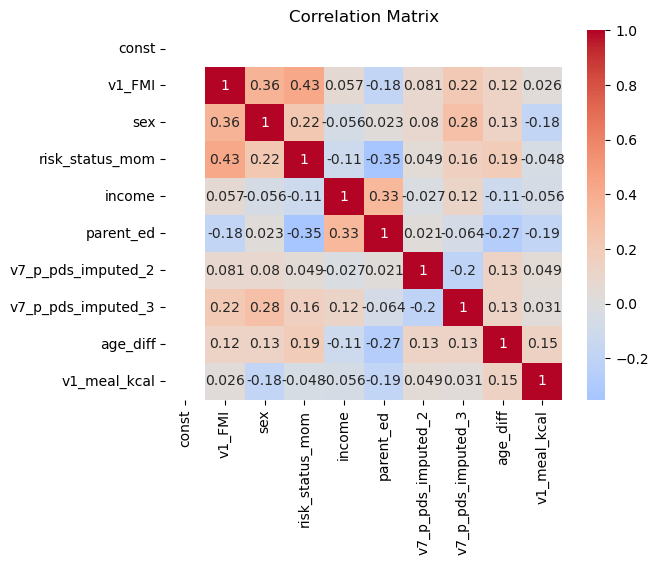

             Variable        VIF
0               const  16.792757
1              v1_FMI   1.424666
2                 sex   1.344413
3     risk_status_mom   1.405460
4              income   1.195764
5           parent_ed   1.410512
6  v7_p_pds_imputed_2   1.109034
7  v7_p_pds_imputed_3   1.231037
8            age_diff   1.158485
9        v1_meal_kcal   1.123141
CHECKING FOR HETEROSKEDASTICITY


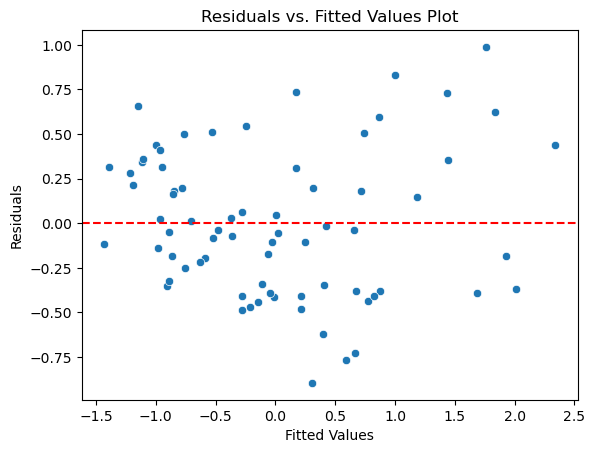

NORMALITY


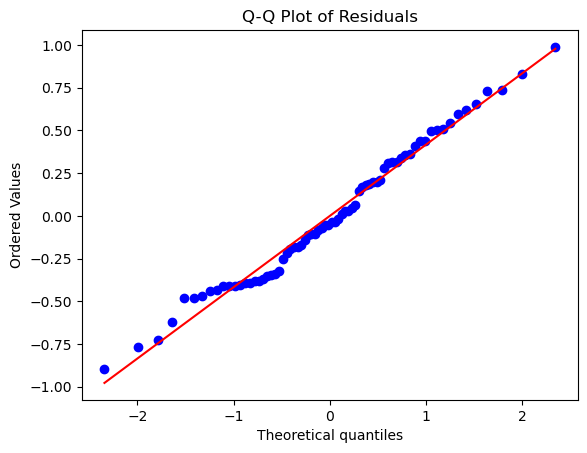

Shapiro-Wilk Test Results:
Statistic: 0.9816564321517944
p-value: 0.3766467273235321
Residuals are normally distributed (fail to reject null hypothesis)


In [70]:
# checking for model assumptions
# Calculate the residuals
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
residuals_mealkcalFMI= mod_mealkcalFMI.resid

# 1. Linearity
# partial regression plots - refer later

# 2. Multicollinearity
print("MULTICOLLINEARITY and AUTOCORRELATION")
dw_statistic_mealkcalFMI = durbin_watson(residuals_mealkcalFMI)
print("Durbin-Watson Statistic:", dw_statistic_mealkcalFMI)
if 0 < dw_statistic_mealkcalFMI < 4:
    print("The Durbin-Watson statistic suggests no significant autocorrelation.")
else:
    print("The Durbin-Watson statistic indicates potential autocorrelation.")

correlation_matrix = X_mealkcalFMI.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_mealkcalFMI.columns
vif_data["VIF"] = [variance_inflation_factor(X_mealkcalFMI.values, i) for i in range(X_mealkcalFMI.shape[1])]
print(vif_data)

# 5. Heteroskedasticity Assumption
print("CHECKING FOR HETEROSKEDASTICITY")
sns.scatterplot(x=mod_mealkcalFMI.fittedvalues, y=residuals_mealkcalFMI)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values Plot")
plt.show()

    
# 4. Normal Distribution of Error Terms Assumption
# Create a Q-Q plot
print("NORMALITY")
stats.probplot(residuals_mealkcalFMI, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Perform Shapiro-Wilk test for normality
statistic_mealkcalFMI, p_value_mealkcalFMI = shapiro(residuals_mealkcalFMI)

# Print the test results
print("Shapiro-Wilk Test Results:")
print("Statistic:", statistic_mealkcalFMI)
print("p-value:", p_value_mealkcalFMI)

# Check the p-value to determine whether residuals are normally distributed
alpha = 0.05  # Significance level
if p_value_mealkcalFMI > alpha:
    print("Residuals are normally distributed (fail to reject null hypothesis)")
else:
    print("Residuals are not normally distributed (reject null hypothesis)")

### Model : EAH (kcal) at baseline (V1) vs V7 FMI
#### covariates baseline FMI, sex, risk status based on maternal weight,tanner stage category at baseline, parent education, parent yearly income, main predictor: baseline EAH intake (kcal)

In [71]:
# Select specific columns as predictors (X) and response (y)

X_EAHkcalFMI = df_linear_reg[['v1_FMI','sex', 'risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff','v1_eah_kcal']]
y_EAHkcalFMI = df_linear_reg['v7_FMI']


# Add a constant term to the predictors (intercept)
X_EAHkcalFMI = sm.add_constant(X_EAHkcalFMI)

# Fit a linear regression model using ols
mod_EAHkcalFMI = sm.OLS(y_EAHkcalFMI, X_EAHkcalFMI).fit()

# Get summary of the regression model
print(mod_EAHkcalFMI.summary())

                            OLS Regression Results                            
Dep. Variable:                 v7_FMI   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     38.15
Date:                Wed, 13 Dec 2023   Prob (F-statistic):           5.48e-22
Time:                        10:05:24   Log-Likelihood:                -34.572
No. Observations:                  72   AIC:                             89.14
Df Residuals:                      62   BIC:                             111.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.3035      0

MULTICOLLINEARITY and AUTOCORRELATION
Durbin-Watson Statistic: 1.5926986961436571
The Durbin-Watson statistic suggests no significant autocorrelation.


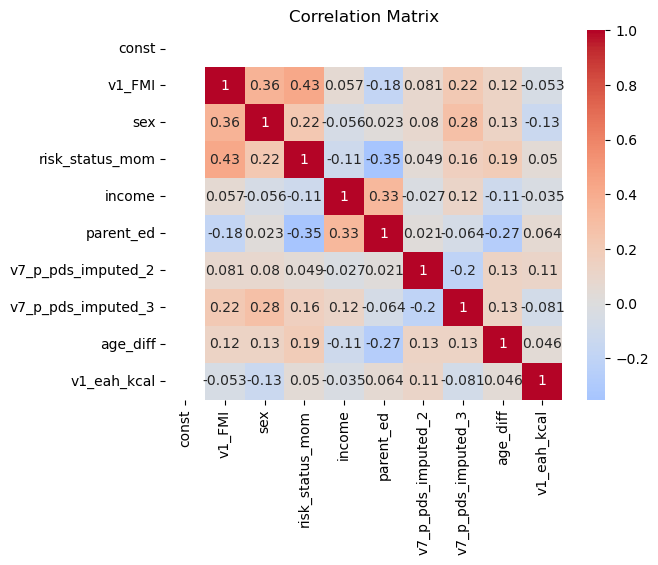

             Variable        VIF
0               const  16.227206
1              v1_FMI   1.413444
2                 sex   1.312240
3     risk_status_mom   1.399651
4              income   1.198833
5           parent_ed   1.401301
6  v7_p_pds_imputed_2   1.114889
7  v7_p_pds_imputed_3   1.223051
8            age_diff   1.145679
9         v1_eah_kcal   1.060386
CHECKING FOR HETEROSKEDASTICITY


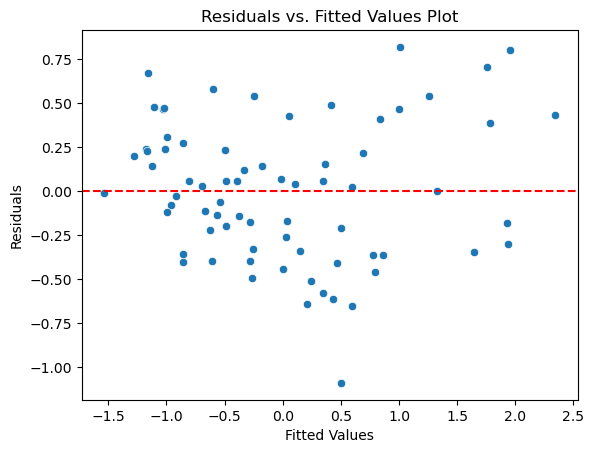

NORMALITY


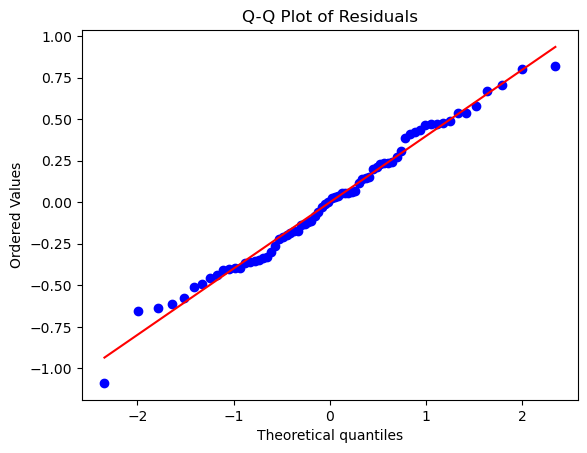

Shapiro-Wilk Test Results:
Statistic: 0.9863229393959045
p-value: 0.6274457573890686
Residuals are normally distributed (fail to reject null hypothesis)


In [72]:
# checking for model assumptions
# Calculate the residuals
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
residuals_EAHkcalFMI = mod_EAHkcalFMI.resid

# 1. Linearity
# partial regression plots - refer later

# 2. Multicollinearity
print("MULTICOLLINEARITY and AUTOCORRELATION")
dw_statistic_EAHkcalFMI = durbin_watson(residuals_EAHkcalFMI)
print("Durbin-Watson Statistic:", dw_statistic_EAHkcalFMI)
if 0 < dw_statistic_EAHkcalFMI < 4:
    print("The Durbin-Watson statistic suggests no significant autocorrelation.")
else:
    print("The Durbin-Watson statistic indicates potential autocorrelation.")

correlation_matrix = X_EAHkcalFMI.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_EAHkcalFMI.columns
vif_data["VIF"] = [variance_inflation_factor(X_EAHkcalFMI.values, i) for i in range(X_EAHkcalFMI.shape[1])]
print(vif_data)

# 3. Heteroskedasticity Assumption
print("CHECKING FOR HETEROSKEDASTICITY")
sns.scatterplot(x=mod_EAHkcalFMI.fittedvalues, y=residuals_EAHkcalFMI)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values Plot")
plt.show()

    
# 4. Normal Distribution of Error Terms Assumption
# Create a Q-Q plot
print("NORMALITY")
stats.probplot(residuals_EAHkcalFMI, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Perform Shapiro-Wilk test for normality
statistic_EAHkcalFMI, p_value_EAHkcalFMI = shapiro(residuals_EAHkcalFMI)

# Print the test results
print("Shapiro-Wilk Test Results:")
print("Statistic:", statistic_EAHkcalFMI)
print("p-value:", p_value_EAHkcalFMI)

# Check the p-value to determine whether residuals are normally distributed
alpha = 0.05  # Significance level
if p_value_EAHkcalFMI > alpha:
    print("Residuals are normally distributed (fail to reject null hypothesis)")
else:
    print("Residuals are not normally distributed (reject null hypothesis)")

### Model : EAH Sweet (kcal) at baseline (V1) vs V7 FMI
#### covariates baseline FMI, sex, risk status based on maternal weight, tanner stage category at baseline, parent education, parent yearly income, main predictor: baseline EAH Sweet intake (kcal)

In [73]:
# Select specific columns as predictors (X) and response (y)
X_EAHsweetkcalFMI = df_linear_reg[['v1_FMI','sex', 'risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff', 'v1_eah_sweet_kcal']]
y_EAHsweetkcalFMI = df_linear_reg['v7_FMI']
'v7_age_yr','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff',
# Add a constant term to the predictors (intercept)
X_EAHsweetkcalFMI = sm.add_constant(X_EAHsweetkcalFMI)

# Fit a linear regression model using ols
mod_EAHsweetkcalFMI = sm.OLS(y_EAHsweetkcalFMI, X_EAHsweetkcalFMI).fit()

# Get summary of the regression model
print(mod_EAHsweetkcalFMI.summary())

                            OLS Regression Results                            
Dep. Variable:                 v7_FMI   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     37.53
Date:                Wed, 13 Dec 2023   Prob (F-statistic):           8.35e-22
Time:                        10:05:48   Log-Likelihood:                -35.072
No. Observations:                  72   AIC:                             90.14
Df Residuals:                      62   BIC:                             112.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.3083      0

MULTICOLLINEARITY and AUTOCORRELATION
Durbin-Watson Statistic: 1.5660671833017654
The Durbin-Watson statistic suggests no significant autocorrelation.


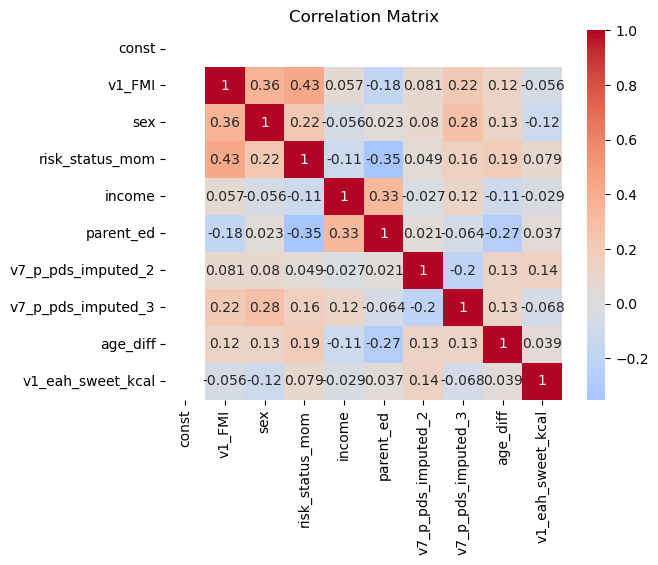

             Variable        VIF
0               const  16.241183
1              v1_FMI   1.416626
2                 sex   1.307844
3     risk_status_mom   1.408671
4              income   1.196665
5           parent_ed   1.392040
6  v7_p_pds_imputed_2   1.124721
7  v7_p_pds_imputed_3   1.222585
8            age_diff   1.142857
9   v1_eah_sweet_kcal   1.064750
CHECKING FOR HETEROSKEDASTICITY


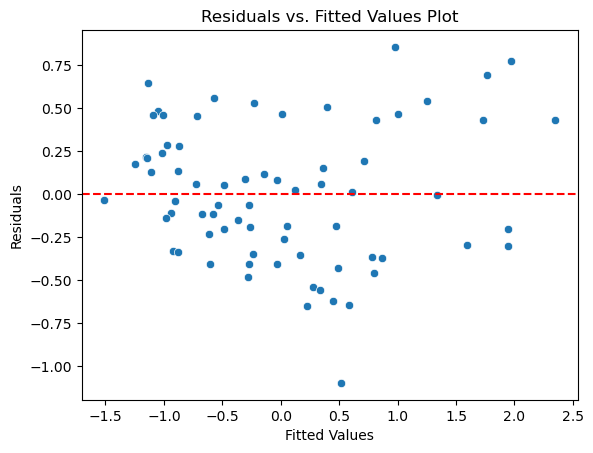

NORMALITY


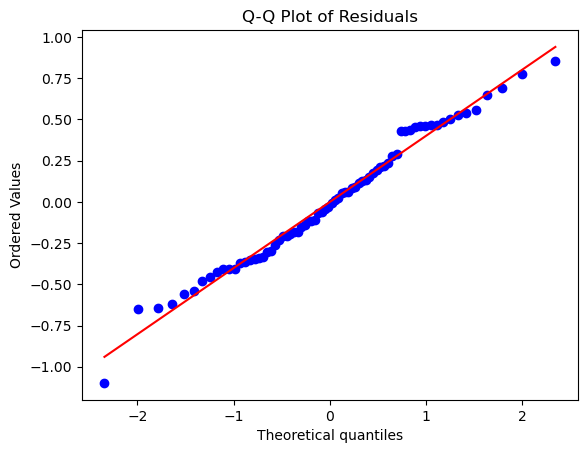

Shapiro-Wilk Test Results:
Statistic: 0.9841639995574951
p-value: 0.5023406147956848
Residuals are normally distributed (fail to reject null hypothesis)


In [74]:
# checking for model assumptions
# Calculate the residuals
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
residuals_EAHsweetkcalFMI = mod_EAHsweetkcalFMI.resid

# 1. Linearity
# partial regression plots - refer later

# 2. Multicollinearity
print("MULTICOLLINEARITY and AUTOCORRELATION")
dw_statistic_EAHsweetkcalFMI = durbin_watson(residuals_EAHsweetkcalFMI)
print("Durbin-Watson Statistic:", dw_statistic_EAHsweetkcalFMI)
if 0 < dw_statistic_EAHsweetkcalFMI < 4:
    print("The Durbin-Watson statistic suggests no significant autocorrelation.")
else:
    print("The Durbin-Watson statistic indicates potential autocorrelation.")

correlation_matrix = X_EAHsweetkcalFMI.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_EAHsweetkcalFMI.columns
vif_data["VIF"] = [variance_inflation_factor(X_EAHsweetkcalFMI.values, i) for i in range(X_EAHsweetkcalFMI.shape[1])]
print(vif_data)

# 3. Heteroskedasticity Assumption
print("CHECKING FOR HETEROSKEDASTICITY")
sns.scatterplot(x=mod_EAHsweetkcalFMI.fittedvalues, y=residuals_EAHsweetkcalFMI)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values Plot")
plt.show()

    
# 4. Normal Distribution of Error Terms Assumption
# Create a Q-Q plot
print("NORMALITY")
stats.probplot(residuals_EAHsweetkcalFMI, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Perform Shapiro-Wilk test for normality
statistic_EAHsweetkcalFMI, p_value_EAHsweetkcalFMI = shapiro(residuals_EAHsweetkcalFMI)

# Print the test results
print("Shapiro-Wilk Test Results:")
print("Statistic:", statistic_EAHsweetkcalFMI)
print("p-value:", p_value_EAHsweetkcalFMI)

# Check the p-value to determine whether residuals are normally distributed
alpha = 0.05  # Significance level
if p_value_EAHsweetkcalFMI > alpha:
    print("Residuals are normally distributed (fail to reject null hypothesis)")
else:
    print("Residuals are not normally distributed (reject null hypothesis)")

### Model : EAH savory (kcal) at baseline (V1) vs V7 FMI
#### covariates baseline FMI, sex, risk status based on maternal weight, tanner stage category at baseline, parent education, parent yearly income, main predictor: baseline EAH savory intake (kcal)

In [75]:
# Select specific columns as predictors (X) and response (y)
X_EAHsavkcalFMI = df_linear_reg[['v1_FMI','sex', 'risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff','v1_eah_sav_kcal']]
y_EAHsavkcalFMI = df_linear_reg['v7_FMI']

# Add a constant term to the predictors (intercept)
X_EAHsavkcalFMI = sm.add_constant(X_EAHsavkcalFMI)

# Fit a linear regression model using ols
mod_EAHsavkcalFMI = sm.OLS(y_EAHsavkcalFMI, X_EAHsavkcalFMI).fit()

# Get summary of the regression model
print(mod_EAHsavkcalFMI.summary())

                            OLS Regression Results                            
Dep. Variable:                 v7_FMI   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     34.26
Date:                Wed, 13 Dec 2023   Prob (F-statistic):           8.51e-21
Time:                        10:06:05   Log-Likelihood:                -37.825
No. Observations:                  72   AIC:                             95.65
Df Residuals:                      62   BIC:                             118.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.2841      0

MULTICOLLINEARITY and AUTOCORRELATION
Durbin-Watson Statistic: 1.6294665287475276
The Durbin-Watson statistic suggests no significant autocorrelation.


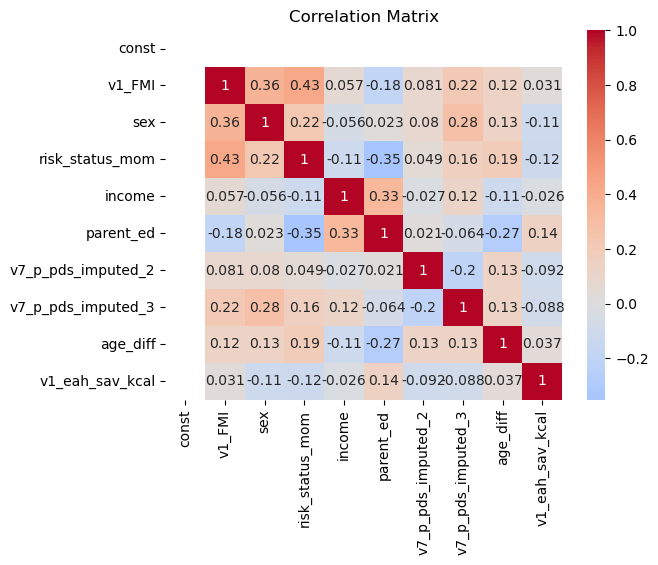

             Variable        VIF
0               const  16.271014
1              v1_FMI   1.451936
2                 sex   1.307357
3     risk_status_mom   1.395655
4              income   1.206950
5           parent_ed   1.426337
6  v7_p_pds_imputed_2   1.122840
7  v7_p_pds_imputed_3   1.231282
8            age_diff   1.158369
9     v1_eah_sav_kcal   1.100573
CHECKING FOR HETEROSKEDASTICITY


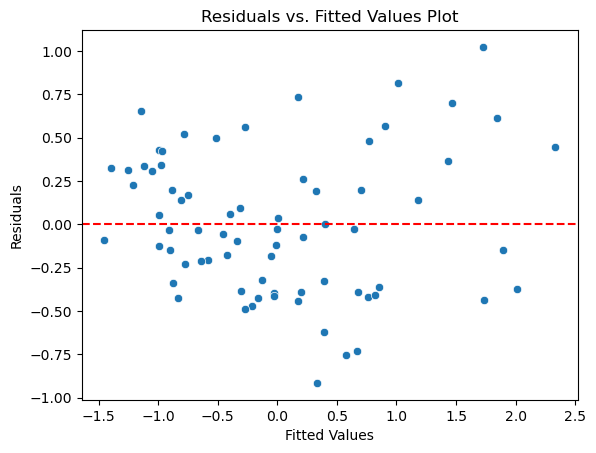

NORMALITY


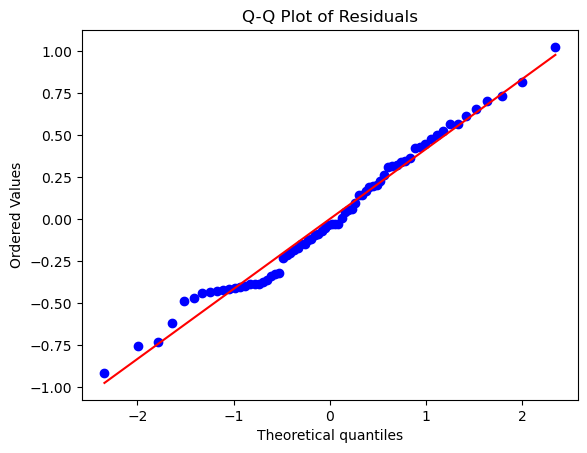

Shapiro-Wilk Test Results:
Statistic: 0.9829009175300598
p-value: 0.4359371066093445
Residuals are normally distributed (fail to reject null hypothesis)


In [76]:
# checking for model assumptions
# Calculate the residuals
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
residuals_EAHsavkcalFMI = mod_EAHsavkcalFMI.resid

# 1. Linearity
# partial regression plots - refer later

# 2. Multicollinearity
print("MULTICOLLINEARITY and AUTOCORRELATION")
dw_statistic_EAHsavkcalFMI = durbin_watson(residuals_EAHsavkcalFMI)
print("Durbin-Watson Statistic:", dw_statistic_EAHsavkcalFMI)
if 0 < dw_statistic_EAHsavkcalFMI < 4:
    print("The Durbin-Watson statistic suggests no significant autocorrelation.")
else:
    print("The Durbin-Watson statistic indicates potential autocorrelation.")

correlation_matrix = X_EAHsavkcalFMI.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_EAHsavkcalFMI.columns
vif_data["VIF"] = [variance_inflation_factor(X_EAHsavkcalFMI.values, i) for i in range(X_EAHsavkcalFMI.shape[1])]
print(vif_data)

# 3. Heteroskedasticity Assumption
print("CHECKING FOR HETEROSKEDASTICITY")
sns.scatterplot(x=mod_EAHsavkcalFMI.fittedvalues, y=residuals_EAHsavkcalFMI)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values Plot")
plt.show()
    
# 4. Normal Distribution of Error Terms Assumption
# Create a Q-Q plot
print("NORMALITY")
stats.probplot(residuals_EAHsavkcalFMI, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Perform Shapiro-Wilk test for normality
statistic_EAHsavkcalFMI, p_value_EAHsavkcalFMI = shapiro(residuals_EAHsavkcalFMI)

# Print the test results
print("Shapiro-Wilk Test Results:")
print("Statistic:", statistic_EAHsavkcalFMI)
print("p-value:", p_value_EAHsavkcalFMI)

# Check the p-value to determine whether residuals are normally distributed
alpha = 0.05  # Significance level
if p_value_EAHsavkcalFMI > alpha:
    print("Residuals are normally distributed (fail to reject null hypothesis)")
else:
    print("Residuals are not normally distributed (reject null hypothesis)")

## Regression models : Baseline intake (kcal) vs follow-up weight status (BMIz)

### Model : Meal (kcal) at baseline (V1) vs V7 weight status BMIz
#### covariates : baseline BMIz, sex, risk status based on maternal weight, tanner stage category at baseline, parent education, parent yearly income, main predictor: baseline meal intake (kcal)

In [77]:
# Select specific columns as predictors (X) and response (y)
X_mealkcalBMIz = df_linear_reg[['bmi_z','sex', 'risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff', 'v1_meal_kcal']]
y_mealkcalBMIz = df_linear_reg['v7_bmi_z']

# Add a constant term to the predictors (intercept)
X_mealkcalBMIz = sm.add_constant(X_mealkcalBMIz)

# Fit a linear regression model using ols
mod_mealkcalBMIz = sm.OLS(y_mealkcalBMIz, X_mealkcalBMIz).fit()

# Get summary of the regression model
print(mod_mealkcalBMIz.summary())

                            OLS Regression Results                            
Dep. Variable:               v7_bmi_z   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     40.17
Date:                Wed, 13 Dec 2023   Prob (F-statistic):           1.44e-22
Time:                        10:06:24   Log-Likelihood:                -19.099
No. Observations:                  72   AIC:                             58.20
Df Residuals:                      62   BIC:                             80.96
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.4411      0

MULTICOLLINEARITY and AUTOCORRELATION
Durbin-Watson Statistic: 1.9432350482769476
The Durbin-Watson statistic suggests no significant autocorrelation.


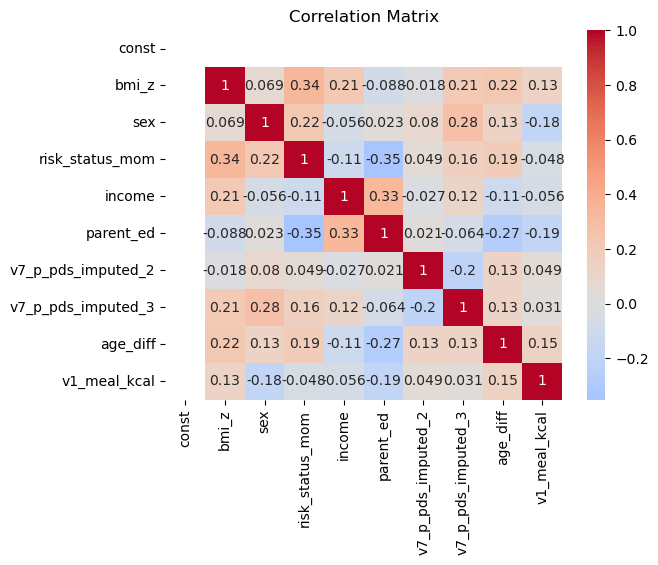

             Variable        VIF
0               const  17.812021
1               bmi_z   1.320650
2                 sex   1.222090
3     risk_status_mom   1.397265
4              income   1.255756
5           parent_ed   1.395066
6  v7_p_pds_imputed_2   1.105737
7  v7_p_pds_imputed_3   1.235494
8            age_diff   1.192852
9        v1_meal_kcal   1.139986
CHECKING FOR HETEROSKEDASTICITY


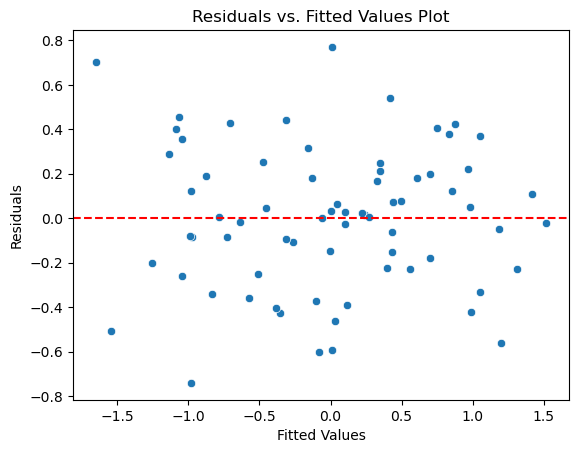

NORMALITY


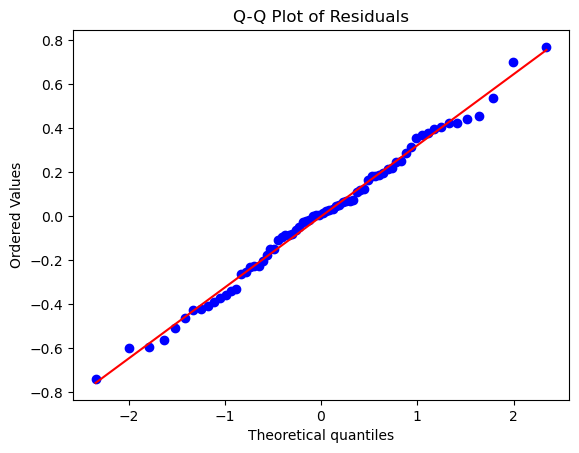

Shapiro-Wilk Test Results:
Statistic: 0.9923533797264099
p-value: 0.9442600607872009
Residuals are normally distributed (fail to reject null hypothesis)


In [78]:
# checking for model assumptions
# Calculate the residuals
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
residuals_mealkcalBMIz= mod_mealkcalBMIz.resid

# 1. Linearity
# partial regression plots - refer later

# 2. Multicollinearity
print("MULTICOLLINEARITY and AUTOCORRELATION")
dw_statistic_mealkcalBMIz = durbin_watson(residuals_mealkcalBMIz)
print("Durbin-Watson Statistic:", dw_statistic_mealkcalBMIz)
if 0 < dw_statistic_mealkcalBMIz < 4:
    print("The Durbin-Watson statistic suggests no significant autocorrelation.")
else:
    print("The Durbin-Watson statistic indicates potential autocorrelation.")

correlation_matrix = X_mealkcalBMIz.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_mealkcalBMIz.columns
vif_data["VIF"] = [variance_inflation_factor(X_mealkcalBMIz.values, i) for i in range(X_mealkcalBMIz.shape[1])]
print(vif_data)

# 3. Heteroskedasticity Assumption
print("CHECKING FOR HETEROSKEDASTICITY")
sns.scatterplot(x=mod_mealkcalBMIz.fittedvalues, y=residuals_mealkcalBMIz)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values Plot")
plt.show()

    
# 4. Normal Distribution of Error Terms Assumption
# Create a Q-Q plot
print("NORMALITY")
stats.probplot(residuals_mealkcalBMIz, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Perform Shapiro-Wilk test for normality
statistic_mealkcalBMIz, p_value_mealkcalBMIz = shapiro(residuals_mealkcalBMIz)

# Print the test results
print("Shapiro-Wilk Test Results:")
print("Statistic:", statistic_mealkcalBMIz)
print("p-value:", p_value_mealkcalBMIz)

# Check the p-value to determine whether residuals are normally distributed
alpha = 0.05  # Significance level
if p_value_mealkcalBMIz > alpha:
    print("Residuals are normally distributed (fail to reject null hypothesis)")
else:
    print("Residuals are not normally distributed (reject null hypothesis)")

### Model : EAH (kcal) at baseline (V1) vs V7 weight status BMIz
#### covariates : baseline BMIz, sex, risk status based on maternal weight, tanner stage category at baseline, parent education, parent yearly income, main predictor: baseline EAH intake (kcal)

In [79]:
# Select specific columns as predictors (X) and response (y)
X_EAHkcalBMIz = df_linear_reg[['bmi_z','sex', 'risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff', 'v1_eah_kcal']]
y_EAHkcalBMIz = df_linear_reg['v7_bmi_z']

# Add a constant term to the predictors (intercept)
X_EAHkcalBMIz = sm.add_constant(X_EAHkcalBMIz)

# Fit a linear regression model using ols
mod_EAHkcalBMIz = sm.OLS(y_EAHkcalBMIz, X_EAHkcalBMIz).fit()

# Get summary of the regression model
print(mod_EAHkcalBMIz.summary())

                            OLS Regression Results                            
Dep. Variable:               v7_bmi_z   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     40.58
Date:                Wed, 13 Dec 2023   Prob (F-statistic):           1.10e-22
Time:                        10:07:27   Log-Likelihood:                -18.786
No. Observations:                  72   AIC:                             57.57
Df Residuals:                      62   BIC:                             80.34
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.4696      0

MULTICOLLINEARITY and AUTOCORRELATION
Durbin-Watson Statistic: 1.8563323921430182
The Durbin-Watson statistic suggests no significant autocorrelation.


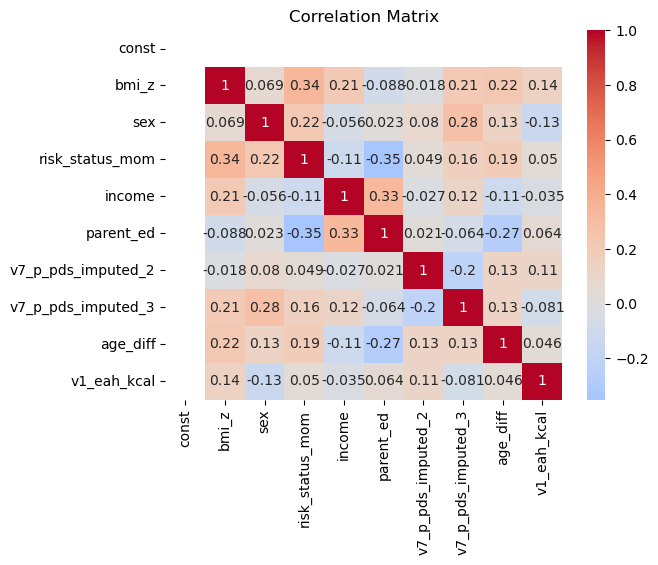

             Variable        VIF
0               const  17.051141
1               bmi_z   1.320038
2                 sex   1.207606
3     risk_status_mom   1.371581
4              income   1.264921
5           parent_ed   1.382533
6  v7_p_pds_imputed_2   1.110365
7  v7_p_pds_imputed_3   1.230508
8            age_diff   1.184157
9         v1_eah_kcal   1.084331
CHECKING FOR HETEROSKEDASTICITY


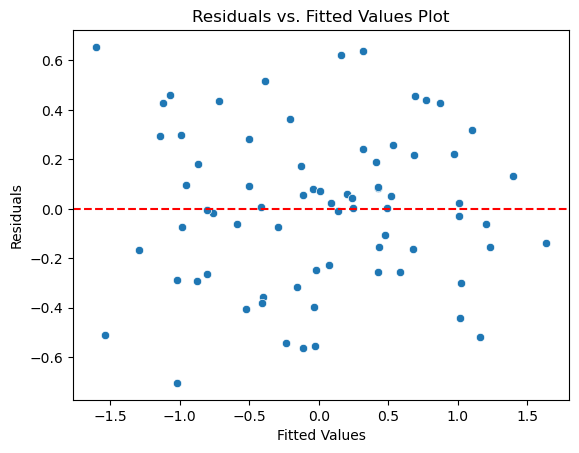

NORMALITY


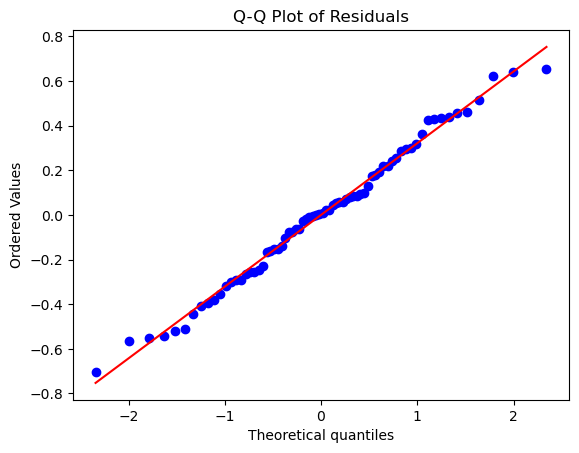

Shapiro-Wilk Test Results:
Statistic: 0.9871490001678467
p-value: 0.6775251030921936
Residuals are normally distributed (fail to reject null hypothesis)


In [80]:
# checking for model assumptions
# Calculate the residuals
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
residuals_EAHkcalBMIz= mod_EAHkcalBMIz.resid

# 1. Linearity
# partial regression plots - refer later

# 2. Multicollinearity
print("MULTICOLLINEARITY and AUTOCORRELATION")
dw_statistic_EAHkcalBMIz = durbin_watson(residuals_EAHkcalBMIz)
print("Durbin-Watson Statistic:", dw_statistic_EAHkcalBMIz)
if 0 < dw_statistic_EAHkcalBMIz < 4:
    print("The Durbin-Watson statistic suggests no significant autocorrelation.")
else:
    print("The Durbin-Watson statistic indicates potential autocorrelation.")

correlation_matrix = X_EAHkcalBMIz.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_EAHkcalBMIz.columns
vif_data["VIF"] = [variance_inflation_factor(X_EAHkcalBMIz.values, i) for i in range(X_EAHkcalBMIz.shape[1])]
print(vif_data)

# 3. Heteroskedasticity Assumption
print("CHECKING FOR HETEROSKEDASTICITY")
sns.scatterplot(x=mod_EAHkcalBMIz.fittedvalues, y=residuals_EAHkcalBMIz)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values Plot")
plt.show()
    
# 4. Normal Distribution of Error Terms Assumption
# Create a Q-Q plot
print("NORMALITY")
stats.probplot(residuals_EAHkcalBMIz, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Perform Shapiro-Wilk test for normality
statistic_EAHkcalBMIz, p_value_EAHkcalBMIz = shapiro(residuals_EAHkcalBMIz)

# Print the test results
print("Shapiro-Wilk Test Results:")
print("Statistic:", statistic_EAHkcalBMIz)
print("p-value:", p_value_EAHkcalBMIz)

# Check the p-value to determine whether residuals are normally distributed
alpha = 0.05  # Significance level
if p_value_EAHkcalBMIz > alpha:
    print("Residuals are normally distributed (fail to reject null hypothesis)")
else:
    print("Residuals are not normally distributed (reject null hypothesis)")

### Model : EAH sweet (kcal) at baseline (V1) vs V7 weight status BMIz
#### covariates : baseline BMIz, sex, risk status based on maternal weight, tanner stage category at baseline, parent education, parent yearly income, main predictor: baseline EAH sweet intake (kcal)

In [81]:
# Select specific columns as predictors (X) and response (y)
X_EAHsweetkcalBMIz = df_linear_reg[['bmi_z','sex', 'risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff','v1_eah_sweet_kcal']]
y_EAHsweetkcalBMIz = df_linear_reg['v7_bmi_z']

# Add a constant term to the predictors (intercept)
X_EAHsweetkcalBMIz = sm.add_constant(X_EAHsweetkcalBMIz)

# Fit a linear regression model using ols
mod_EAHsweetkcalBMIz= sm.OLS(y_EAHsweetkcalBMIz, X_EAHsweetkcalBMIz).fit()

# Get summary of the regression model
print(mod_EAHsweetkcalBMIz.summary())

                            OLS Regression Results                            
Dep. Variable:               v7_bmi_z   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     40.92
Date:                Wed, 13 Dec 2023   Prob (F-statistic):           8.89e-23
Time:                        10:07:50   Log-Likelihood:                -18.530
No. Observations:                  72   AIC:                             57.06
Df Residuals:                      62   BIC:                             79.83
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.4685      0

MULTICOLLINEARITY and AUTOCORRELATION
Durbin-Watson Statistic: 1.8331505014581941
The Durbin-Watson statistic suggests no significant autocorrelation.


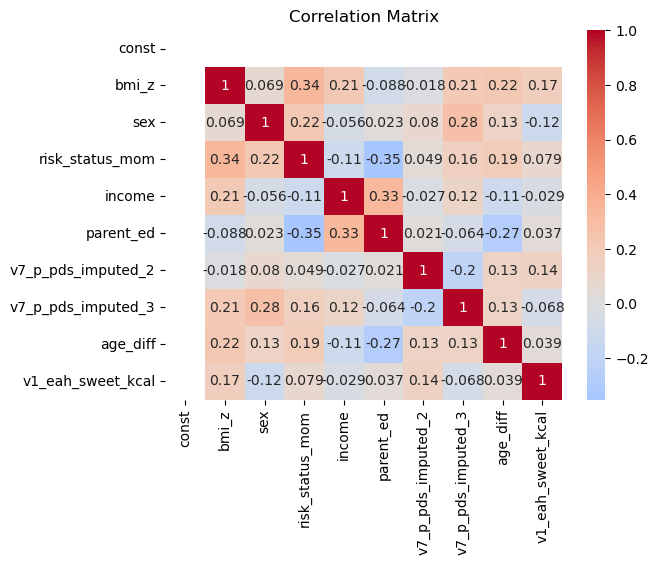

             Variable        VIF
0               const  17.052452
1               bmi_z   1.330390
2                 sex   1.205925
3     risk_status_mom   1.373242
4              income   1.263125
5           parent_ed   1.373791
6  v7_p_pds_imputed_2   1.120281
7  v7_p_pds_imputed_3   1.229551
8            age_diff   1.182778
9   v1_eah_sweet_kcal   1.094868
CHECKING FOR HETEROSKEDASTICITY


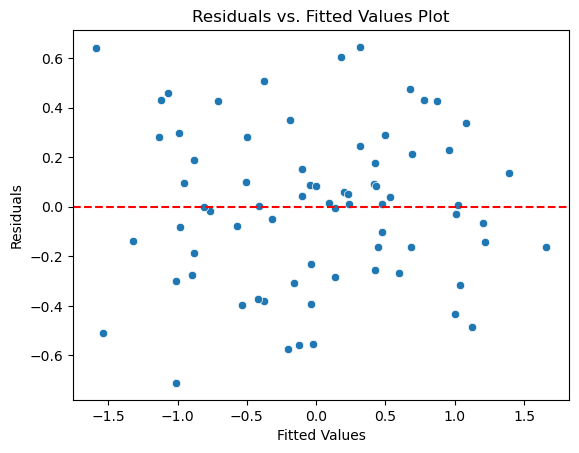

NORMALITY


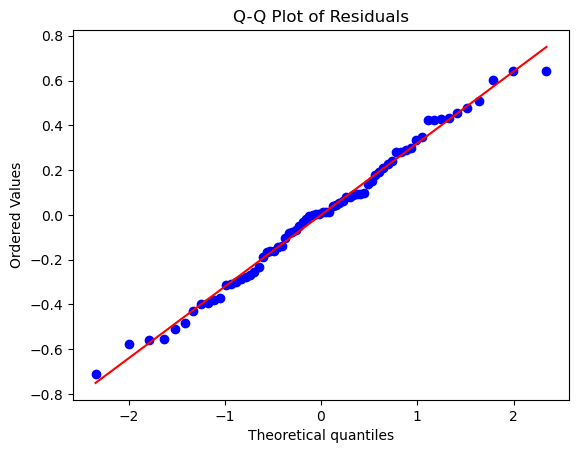

Shapiro-Wilk Test Results:
Statistic: 0.9879482984542847
p-value: 0.7259674072265625
Residuals are normally distributed (fail to reject null hypothesis)


In [82]:
# checking for model assumptions
# Calculate the residuals
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
residuals_EAHsweetkcalBMIz= mod_EAHsweetkcalBMIz.resid

# 1. Linearity
# partial regression plots - refer later

# 2. Multicollinearity
print("MULTICOLLINEARITY and AUTOCORRELATION")
dw_statistic_EAHsweetkcalBMIz = durbin_watson(residuals_EAHsweetkcalBMIz)
print("Durbin-Watson Statistic:", dw_statistic_EAHsweetkcalBMIz)
if 0 < dw_statistic_EAHsweetkcalBMIz < 4:
    print("The Durbin-Watson statistic suggests no significant autocorrelation.")
else:
    print("The Durbin-Watson statistic indicates potential autocorrelation.")

correlation_matrix = X_EAHsweetkcalBMIz.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_EAHsweetkcalBMIz.columns
vif_data["VIF"] = [variance_inflation_factor(X_EAHsweetkcalBMIz.values, i) for i in range(X_EAHsweetkcalBMIz.shape[1])]
print(vif_data)

# 3. Heteroskedasticity Assumption
print("CHECKING FOR HETEROSKEDASTICITY")
sns.scatterplot(x=mod_EAHsweetkcalBMIz.fittedvalues, y=residuals_EAHsweetkcalBMIz)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values Plot")
plt.show()
    
# 4. Normal Distribution of Error Terms Assumption
# Create a Q-Q plot
print("NORMALITY")
stats.probplot(residuals_EAHsweetkcalBMIz, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Perform Shapiro-Wilk test for normality
statistic_EAHsweetkcalBMIz, p_value_EAHsweetkcalBMIz = shapiro(residuals_EAHsweetkcalBMIz)

# Print the test results
print("Shapiro-Wilk Test Results:")
print("Statistic:", statistic_EAHsweetkcalBMIz)
print("p-value:", p_value_EAHsweetkcalBMIz)

# Check the p-value to determine whether residuals are normally distributed
alpha = 0.05  # Significance level
if p_value_EAHsweetkcalBMIz > alpha:
    print("Residuals are normally distributed (fail to reject null hypothesis)")
else:
    print("Residuals are not normally distributed (reject null hypothesis)")

### Model : EAH savory (kcal) at baseline (V1) vs V7 weight status BMIz
#### covariates : baseline BMIz, sex,  risk status based on maternal weight, tanner stage category at baseline, parent education, parent yearly income, main predictor: baseline EAH savory intake (kcal)

In [83]:
# Select specific columns as predictors (X) and response (y)
X_EAHsavkcalBMIz = df_linear_reg[['bmi_z','sex', 'risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff', 'v1_eah_sav_kcal']]
y_EAHsavkcalBMIz = df_linear_reg['v7_bmi_z']

# Add a constant term to the predictors (intercept)
X_EAHsavkcalBMIz = sm.add_constant(X_EAHsavkcalBMIz)

# Fit a linear regression model using ols
mod_EAHsavkcalBMIz= sm.OLS(y_EAHsavkcalBMIz, X_EAHsavkcalBMIz).fit()

# Get summary of the regression model
print(mod_EAHsavkcalBMIz.summary())

                            OLS Regression Results                            
Dep. Variable:               v7_bmi_z   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     39.56
Date:                Wed, 13 Dec 2023   Prob (F-statistic):           2.15e-22
Time:                        10:08:13   Log-Likelihood:                -19.574
No. Observations:                  72   AIC:                             59.15
Df Residuals:                      62   BIC:                             81.91
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.4735      0

MULTICOLLINEARITY and AUTOCORRELATION
Durbin-Watson Statistic: 1.9075782429371515
The Durbin-Watson statistic suggests no significant autocorrelation.


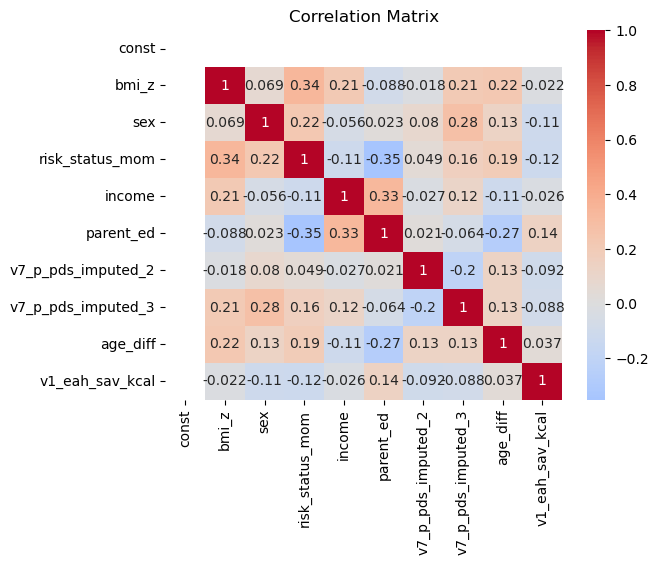

             Variable        VIF
0               const  17.051399
1               bmi_z   1.290655
2                 sex   1.186881
3     risk_status_mom   1.370536
4              income   1.259641
5           parent_ed   1.395077
6  v7_p_pds_imputed_2   1.113454
7  v7_p_pds_imputed_3   1.234980
8            age_diff   1.198014
9     v1_eah_sav_kcal   1.071204
CHECKING FOR HETEROSKEDASTICITY


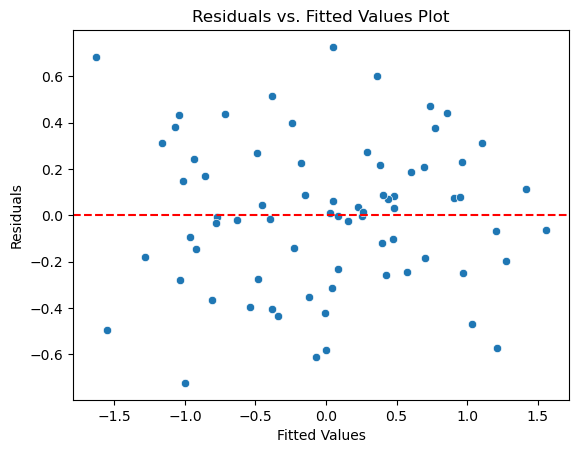

NORMALITY


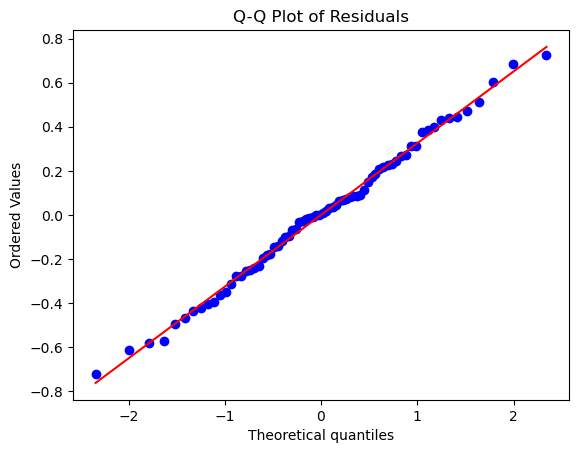

Shapiro-Wilk Test Results:
Statistic: 0.9927862882614136
p-value: 0.9571487903594971
Residuals are normally distributed (fail to reject null hypothesis)


In [84]:
# checking for model assumptions
# Calculate the residuals
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
residuals_EAHsavkcalBMIz= mod_EAHsavkcalBMIz.resid

# 1. Linearity
# partial regression plots - refer later

# 2. Multicollinearity
print("MULTICOLLINEARITY and AUTOCORRELATION")
dw_statistic_EAHsavkcalBMIz = durbin_watson(residuals_EAHsavkcalBMIz)
print("Durbin-Watson Statistic:", dw_statistic_EAHsavkcalBMIz)
if 0 < dw_statistic_EAHsavkcalBMIz < 4:
    print("The Durbin-Watson statistic suggests no significant autocorrelation.")
else:
    print("The Durbin-Watson statistic indicates potential autocorrelation.")

correlation_matrix = X_EAHsavkcalBMIz.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_EAHsavkcalBMIz.columns
vif_data["VIF"] = [variance_inflation_factor(X_EAHsavkcalBMIz.values, i) for i in range(X_EAHsavkcalBMIz.shape[1])]
print(vif_data)

# 3. Heteroskedasticity Assumption
print("CHECKING FOR HETEROSKEDASTICITY")
sns.scatterplot(x=mod_EAHsavkcalBMIz.fittedvalues, y=residuals_EAHsavkcalBMIz)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values Plot")
plt.show()

    
# 4. Normal Distribution of Error Terms Assumption
# Create a Q-Q plot
print("NORMALITY")
stats.probplot(residuals_EAHsavkcalBMIz, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Perform Shapiro-Wilk test for normality
statistic_EAHsavkcalBMIz, p_value_EAHsavkcalBMIz = shapiro(residuals_EAHsavkcalBMIz)

# Print the test results
print("Shapiro-Wilk Test Results:")
print("Statistic:", statistic_EAHsavkcalBMIz)
print("p-value:", p_value_EAHsavkcalBMIz)

# Check the p-value to determine whether residuals are normally distributed
alpha = 0.05  # Significance level
if p_value_EAHsavkcalBMIz > alpha:
    print("Residuals are normally distributed (fail to reject null hypothesis)")
else:
    print("Residuals are not normally distributed (reject null hypothesis)")

## Regression model: Intake (gram) at baseline V1 vs follow-up adiposity (FMI)

### Model : Meal (gram) at baseline (V1) vs V7 follow-up adiposity FMI
#### covariates : baseline FMI, sex, risk status based on maternal weight, tanner stage category at baseline, parent education, parent yearly income, main predictor: baseline meal intake (gram)

In [85]:
# Select specific columns as predictors (X) and response (y)
X_mealgFMI = df_linear_reg[['v1_FMI','sex', 'risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff', 'v1_meal_g']]
y_mealgFMI = df_linear_reg['v7_FMI']

# Add a constant term to the predictors (intercept)
X_mealgFMI = sm.add_constant(X_mealgFMI)

# Fit a linear regression model using ols
mod_mealgFMI= sm.OLS(y_mealgFMI, X_mealgFMI).fit()

# Get summary of the regression model
print(mod_mealgFMI.summary())

                            OLS Regression Results                            
Dep. Variable:                 v7_FMI   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     34.12
Date:                Wed, 13 Dec 2023   Prob (F-statistic):           9.44e-21
Time:                        10:08:50   Log-Likelihood:                -37.948
No. Observations:                  72   AIC:                             95.90
Df Residuals:                      62   BIC:                             118.7
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.2894      0

MULTICOLLINEARITY and AUTOCORRELATION
Durbin-Watson Statistic: 1.6128312035863848
The Durbin-Watson statistic suggests no significant autocorrelation.


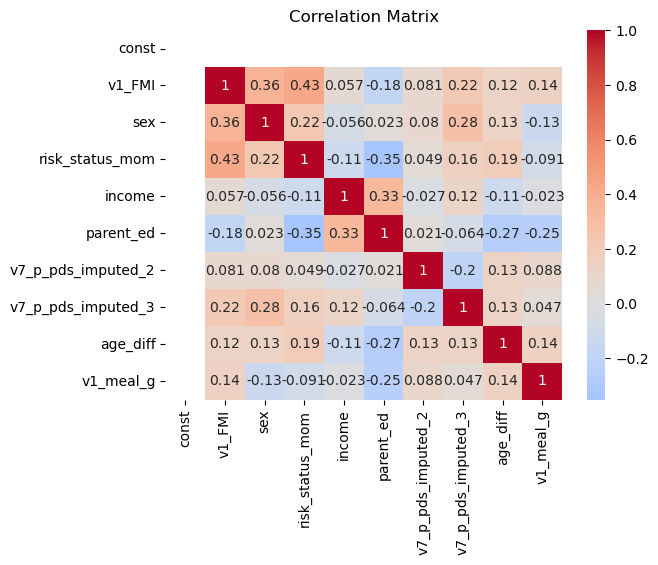

             Variable        VIF
0               const  17.172987
1              v1_FMI   1.486004
2                 sex   1.329745
3     risk_status_mom   1.482430
4              income   1.195070
5           parent_ed   1.479267
6  v7_p_pds_imputed_2   1.118328
7  v7_p_pds_imputed_3   1.231255
8            age_diff   1.149905
9           v1_meal_g   1.225304
CHECKING FOR HETEROSKEDASTICITY


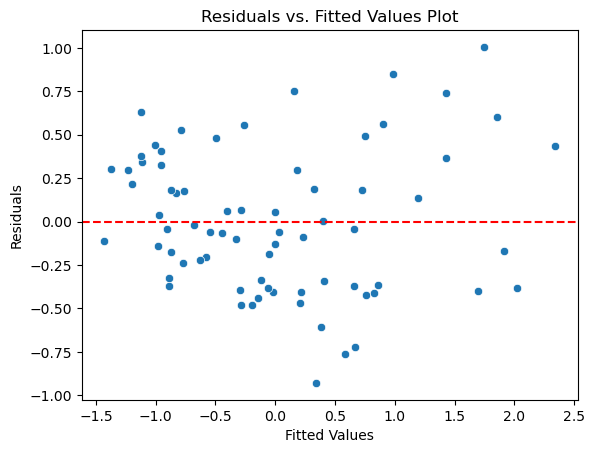

NORMALITY


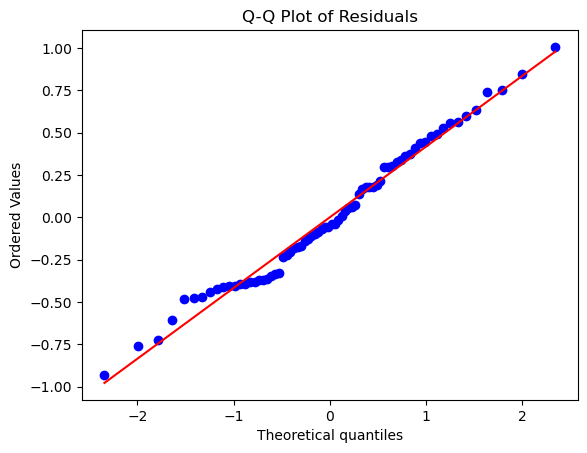

Shapiro-Wilk Test Results:
Statistic: 0.9826064109802246
p-value: 0.42133480310440063
Residuals are normally distributed (fail to reject null hypothesis)


In [86]:
# checking for model assumptions
# Calculate the residuals
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
residuals_mealgFMI= mod_mealgFMI.resid

# 1. Linearity
# partial regression plots - refer later

# 2. Multicollinearity
print("MULTICOLLINEARITY and AUTOCORRELATION")
dw_statistic_mealgFMI = durbin_watson(residuals_mealgFMI)
print("Durbin-Watson Statistic:", dw_statistic_mealgFMI)
if 0 < dw_statistic_mealgFMI < 4:
    print("The Durbin-Watson statistic suggests no significant autocorrelation.")
else:
    print("The Durbin-Watson statistic indicates potential autocorrelation.")

correlation_matrix = X_mealgFMI.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_mealgFMI.columns
vif_data["VIF"] = [variance_inflation_factor(X_mealgFMI.values, i) for i in range(X_mealgFMI.shape[1])]
print(vif_data)

# 3. Heteroskedasticity Assumption
print("CHECKING FOR HETEROSKEDASTICITY")
sns.scatterplot(x=mod_mealgFMI.fittedvalues, y=residuals_mealgFMI)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values Plot")
plt.show()
    
# 4. Normal Distribution of Error Terms Assumption
# Create a Q-Q plot
print("NORMALITY")
stats.probplot(residuals_mealgFMI, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Perform Shapiro-Wilk test for normality
statistic_mealgFMI, p_value_mealgFMI = shapiro(residuals_mealgFMI)

# Print the test results
print("Shapiro-Wilk Test Results:")
print("Statistic:", statistic_mealgFMI)
print("p-value:", p_value_mealgFMI)

# Check the p-value to determine whether residuals are normally distributed
alpha = 0.05  # Significance level
if p_value_mealgFMI > alpha:
    print("Residuals are normally distributed (fail to reject null hypothesis)")
else:
    print("Residuals are not normally distributed (reject null hypothesis)")

### Model : EAH (gram) at baseline (V1) vs V7 follow-up adiposity FMI (v7)
#### covariates : baseline FMI, sex, risk status based on maternal weight, tanner stage category at baseline, parent education, parent yearly income, main predictor: baseline EAH intake (gram)

In [87]:
# Select specific columns as predictors (X) and response (y)
X_EAHgFMI = df_linear_reg[['v1_FMI','sex', 'risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff','v1_eah_g']]
y_EAHgFMI = df_linear_reg['v7_FMI']

# Add a constant term to the predictors (intercept)
X_EAHgFMI = sm.add_constant(X_EAHgFMI)

# Fit a linear regression model using ols
mod_EAHgFMI= sm.OLS(y_EAHgFMI, X_EAHgFMI).fit()

# Get summary of the regression model
print(mod_EAHgFMI.summary())

                            OLS Regression Results                            
Dep. Variable:                 v7_FMI   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     36.04
Date:                Wed, 13 Dec 2023   Prob (F-statistic):           2.34e-21
Time:                        10:09:12   Log-Likelihood:                -36.294
No. Observations:                  72   AIC:                             92.59
Df Residuals:                      62   BIC:                             115.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.2825      0

MULTICOLLINEARITY and AUTOCORRELATION
Durbin-Watson Statistic: 1.5129104854969628
The Durbin-Watson statistic suggests no significant autocorrelation.


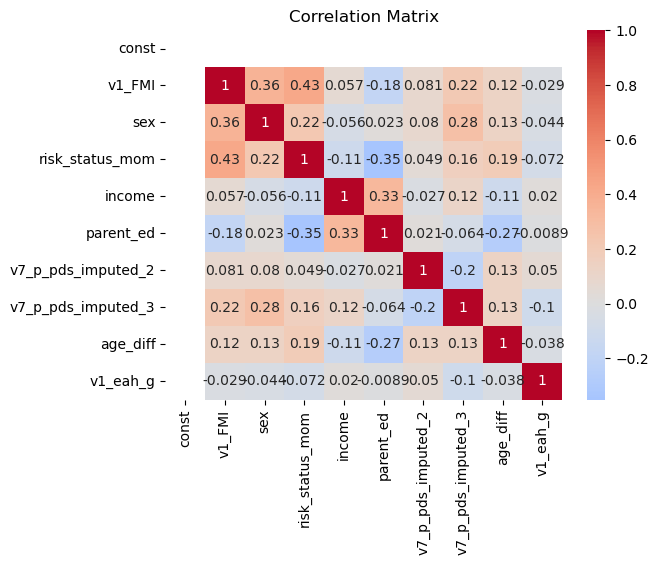

             Variable        VIF
0               const  16.221891
1              v1_FMI   1.412580
2                 sex   1.283440
3     risk_status_mom   1.388157
4              income   1.196207
5           parent_ed   1.383811
6  v7_p_pds_imputed_2   1.105352
7  v7_p_pds_imputed_3   1.229952
8            age_diff   1.142043
9            v1_eah_g   1.018863
CHECKING FOR HETEROSKEDASTICITY


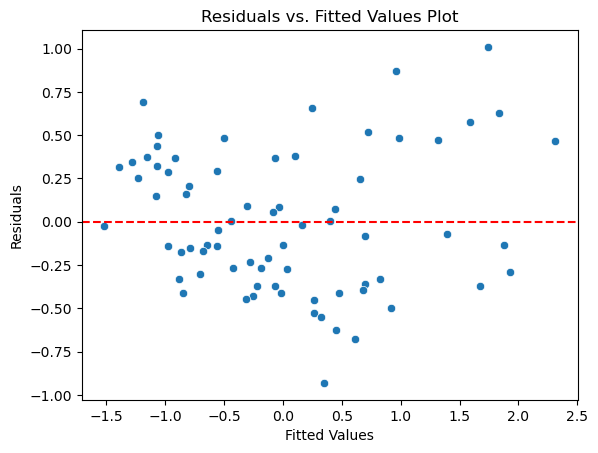

NORMALITY


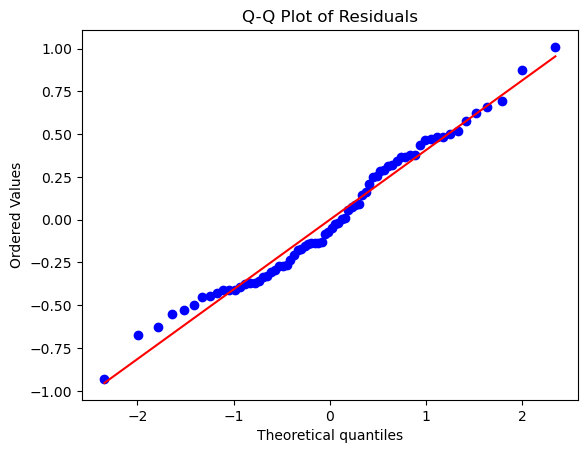

Shapiro-Wilk Test Results:
Statistic: 0.9788405299186707
p-value: 0.2658693194389343
Residuals are normally distributed (fail to reject null hypothesis)


In [88]:
# checking for model assumptions 
# Calculate the residuals
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
residuals_EAHgFMI= mod_EAHgFMI.resid

# 1. Linearity
# partial regression plots - refer later

# 2. Multicollinearity
print("MULTICOLLINEARITY and AUTOCORRELATION")
dw_statistic_EAHgFMI = durbin_watson(residuals_EAHgFMI)
print("Durbin-Watson Statistic:", dw_statistic_EAHgFMI)
if 0 < dw_statistic_EAHgFMI < 4:
    print("The Durbin-Watson statistic suggests no significant autocorrelation.")
else:
    print("The Durbin-Watson statistic indicates potential autocorrelation.")

correlation_matrix = X_EAHgFMI.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_EAHgFMI.columns
vif_data["VIF"] = [variance_inflation_factor(X_EAHgFMI.values, i) for i in range(X_EAHgFMI.shape[1])]
print(vif_data)

# 3. Heteroskedasticity Assumption
print("CHECKING FOR HETEROSKEDASTICITY")
sns.scatterplot(x=mod_EAHgFMI.fittedvalues, y=residuals_EAHgFMI)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values Plot")
plt.show()
    
# 4. Normal Distribution of Error Terms Assumption
# Create a Q-Q plot
print("NORMALITY")
stats.probplot(residuals_EAHgFMI, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Perform Shapiro-Wilk test for normality
statistic_EAHgFMI, p_value_EAHgFMI = shapiro(residuals_EAHgFMI)

# Print the test results
print("Shapiro-Wilk Test Results:")
print("Statistic:", statistic_EAHgFMI)
print("p-value:", p_value_EAHgFMI)

# Check the p-value to determine whether residuals are normally distributed
alpha = 0.05  # Significance level
if p_value_EAHgFMI > alpha:
    print("Residuals are normally distributed (fail to reject null hypothesis)")
else:
    print("Residuals are not normally distributed (reject null hypothesis)")

### Model : EAH sweet (gram) at baseline (V1) vs V7 follow-up adiposity FMI (v7)
#### covariates : baseline FMI, sex, risk status based on maternal weight, tanner stage category at baseline, parent education, parent yearly income, main predictor: baseline EAH sweet intake (gram)

In [89]:
# Select specific columns as predictors (X) and response (y)
X_EAHsweetgFMI = df_linear_reg[['v1_FMI','sex', 'risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff','v1_eah_sweet_g']]
y_EAHsweetgFMI = df_linear_reg['v7_FMI']

# Add a constant term to the predictors (intercept)
X_EAHsweetgFMI = sm.add_constant(X_EAHsweetgFMI)

# Fit a linear regression model using ols
mod_EAHsweetgFMI= sm.OLS(y_EAHsweetgFMI, X_EAHsweetgFMI).fit()

# Get summary of the regression model
print(mod_EAHsweetgFMI.summary())

                            OLS Regression Results                            
Dep. Variable:                 v7_FMI   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     38.39
Date:                Wed, 13 Dec 2023   Prob (F-statistic):           4.64e-22
Time:                        10:09:44   Log-Likelihood:                -34.374
No. Observations:                  72   AIC:                             88.75
Df Residuals:                      62   BIC:                             111.5
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.3020      0

MULTICOLLINEARITY and AUTOCORRELATION
Durbin-Watson Statistic: 1.4982548352138414
The Durbin-Watson statistic suggests no significant autocorrelation.


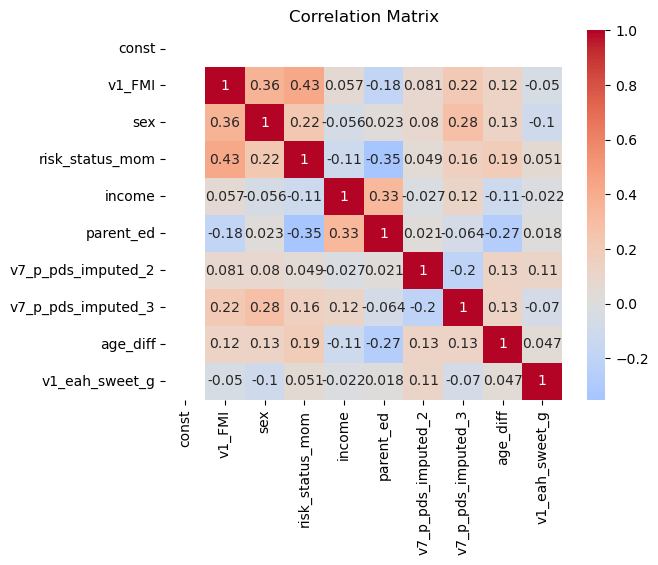

             Variable        VIF
0               const  16.224075
1              v1_FMI   1.414998
2                 sex   1.298121
3     risk_status_mom   1.394515
4              income   1.195366
5           parent_ed   1.384917
6  v7_p_pds_imputed_2   1.114887
7  v7_p_pds_imputed_3   1.223094
8            age_diff   1.143852
9      v1_eah_sweet_g   1.038785
CHECKING FOR HETEROSKEDASTICITY


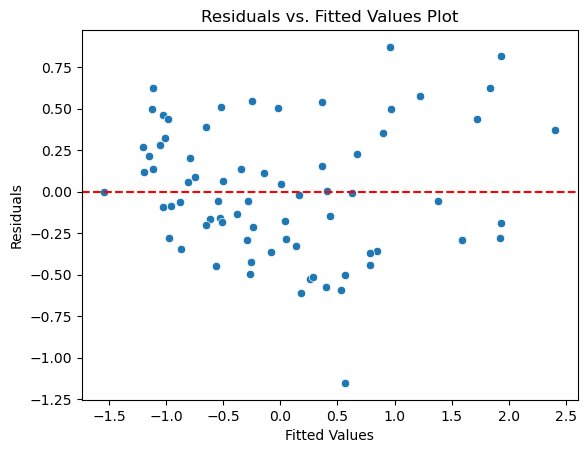

NORMALITY


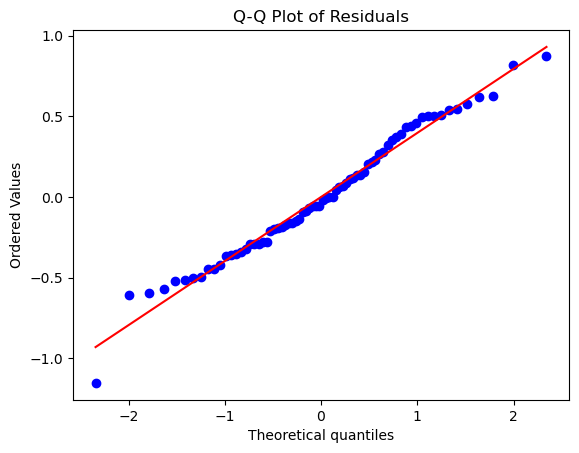

Shapiro-Wilk Test Results:
Statistic: 0.9831194877624512
p-value: 0.4469931125640869
Residuals are normally distributed (fail to reject null hypothesis)


In [90]:
# checking for model assumptions
# Calculate the residuals
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
residuals_EAHsweetgFMI= mod_EAHsweetgFMI.resid

# 1. Linearity
# partial regression plots - refer later

# 2. Multicollinearity
print("MULTICOLLINEARITY and AUTOCORRELATION")
dw_statistic_EAHsweetgFMI = durbin_watson(residuals_EAHsweetgFMI)
print("Durbin-Watson Statistic:", dw_statistic_EAHsweetgFMI)
if 0 < dw_statistic_EAHsweetgFMI < 4:
    print("The Durbin-Watson statistic suggests no significant autocorrelation.")
else:
    print("The Durbin-Watson statistic indicates potential autocorrelation.")

correlation_matrix = X_EAHsweetgFMI.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_EAHsweetgFMI.columns
vif_data["VIF"] = [variance_inflation_factor(X_EAHsweetgFMI.values, i) for i in range(X_EAHsweetgFMI.shape[1])]
print(vif_data)

# 3. Heteroskedasticity Assumption
print("CHECKING FOR HETEROSKEDASTICITY")
sns.scatterplot(x=mod_EAHsweetgFMI.fittedvalues, y=residuals_EAHsweetgFMI)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values Plot")
plt.show()

    
# 4. Normal Distribution of Error Terms Assumption
# Create a Q-Q plot
print("NORMALITY")
stats.probplot(residuals_EAHsweetgFMI, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Perform Shapiro-Wilk test for normality
statistic_EAHsweetgFMI, p_value_EAHsweetgFMI = shapiro(residuals_EAHsweetgFMI)

# Print the test results
print("Shapiro-Wilk Test Results:")
print("Statistic:", statistic_EAHsweetgFMI)
print("p-value:", p_value_EAHsweetgFMI)

# Check the p-value to determine whether residuals are normally distributed
alpha = 0.05  # Significance level
if p_value_EAHsweetgFMI > alpha:
    print("Residuals are normally distributed (fail to reject null hypothesis)")
else:
    print("Residuals are not normally distributed (reject null hypothesis)")

### Model : EAH savory (gram) at baseline (V1) vs V7 follow-up adiposity FMI (v7)
#### covariates : baseline FMI, sex, risk status based on maternal weight, tanner stage category at baseline, parent education, parent yearly income, main predictor: baseline EAH savory intake (gram)

In [91]:
# Select specific columns as predictors (X) and response (y)
X_EAHsavgFMI = df_linear_reg[['v1_FMI','sex', 'risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff','v1_eah_sav_g']]
y_EAHsavgFMI = df_linear_reg['v7_FMI']

# Add a constant term to the predictors (intercept)
X_EAHsavgFMI = sm.add_constant(X_EAHsavgFMI)

# Fit a linear regression model using ols
mod_EAHsavgFMI= sm.OLS(y_EAHsavgFMI, X_EAHsavgFMI).fit()

# Get summary of the regression model
print(mod_EAHsavgFMI.summary())

                            OLS Regression Results                            
Dep. Variable:                 v7_FMI   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     34.26
Date:                Wed, 13 Dec 2023   Prob (F-statistic):           8.50e-21
Time:                        10:10:19   Log-Likelihood:                -37.823
No. Observations:                  72   AIC:                             95.65
Df Residuals:                      62   BIC:                             118.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.2846      0

MULTICOLLINEARITY and AUTOCORRELATION
Durbin-Watson Statistic: 1.628476150689801
The Durbin-Watson statistic suggests no significant autocorrelation.


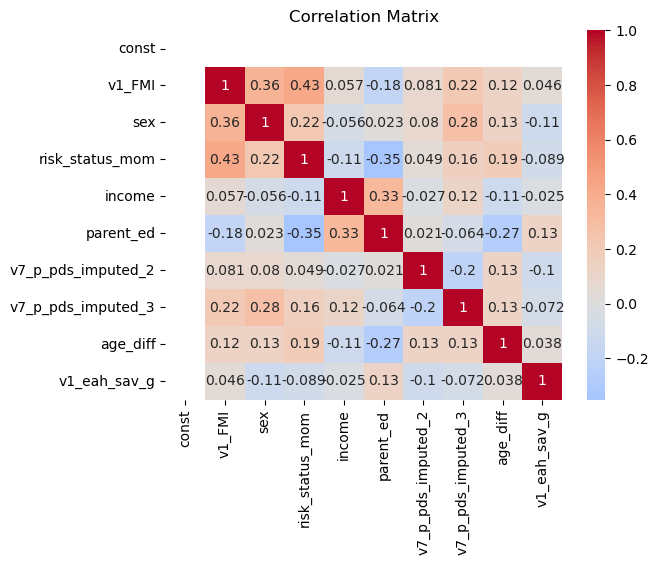

             Variable        VIF
0               const  16.261992
1              v1_FMI   1.453317
2                 sex   1.309929
3     risk_status_mom   1.389754
4              income   1.206438
5           parent_ed   1.425261
6  v7_p_pds_imputed_2   1.124214
7  v7_p_pds_imputed_3   1.228993
8            age_diff   1.156892
9        v1_eah_sav_g   1.093834
CHECKING FOR HETEROSKEDASTICITY


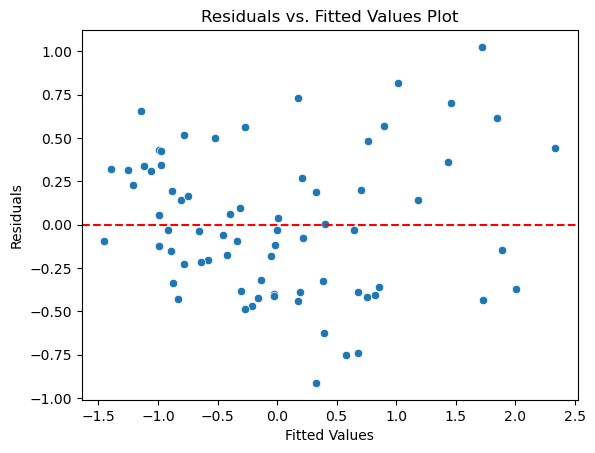

NORMALITY


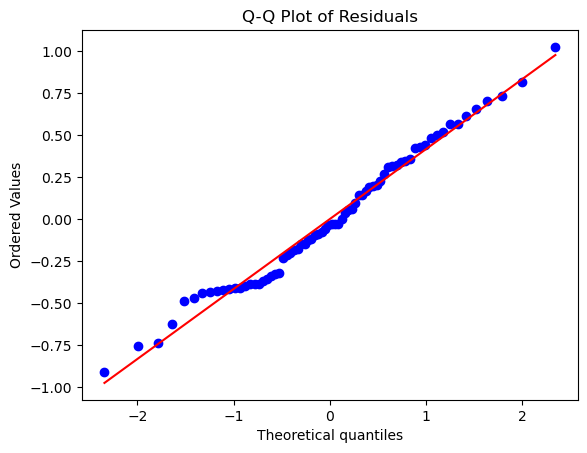

Shapiro-Wilk Test Results:
Statistic: 0.9828314185142517
p-value: 0.4324595630168915
Residuals are normally distributed (fail to reject null hypothesis)


In [97]:
# checking for model assumptions
# Calculate the residuals
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
residuals_EAHsavgFMI= mod_EAHsavgFMI.resid

# 1. Linearity
# partial regression plots - refer later

# 2. Multicollinearity
print("MULTICOLLINEARITY and AUTOCORRELATION")
dw_statistic_EAHsavgFMI = durbin_watson(residuals_EAHsavgFMI)
print("Durbin-Watson Statistic:", dw_statistic_EAHsavgFMI)
if 0 < dw_statistic_EAHsavgFMI < 4:
    print("The Durbin-Watson statistic suggests no significant autocorrelation.")
else:
    print("The Durbin-Watson statistic indicates potential autocorrelation.")

correlation_matrix = X_EAHsavgFMI.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_EAHsavgFMI.columns
vif_data["VIF"] = [variance_inflation_factor(X_EAHsavgFMI.values, i) for i in range(X_EAHsavgFMI.shape[1])]
print(vif_data)

# 3. Heteroskedasticity Assumption
print("CHECKING FOR HETEROSKEDASTICITY")
sns.scatterplot(x=mod_EAHsavgFMI.fittedvalues, y=residuals_EAHsavgFMI)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values Plot")
plt.show()
    
# 4. Normal Distribution of Error Terms Assumption
# Create a Q-Q plot
print("NORMALITY")
stats.probplot(residuals_EAHsavgFMI, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Perform Shapiro-Wilk test for normality
statistic_EAHsavgFMI, p_value_EAHsavgFMI = shapiro(residuals_EAHsavgFMI)

# Print the test results
print("Shapiro-Wilk Test Results:")
print("Statistic:", statistic_EAHsavgFMI)
print("p-value:", p_value_EAHsavgFMI)

# Check the p-value to determine whether residuals are normally distributed
alpha = 0.05  # Significance level 
if p_value_EAHsavgFMI > alpha:
    print("Residuals are normally distributed (fail to reject null hypothesis)")
else:
    print("Residuals are not normally distributed (reject null hypothesis)")

## Regression models: Intake (gram) at baseline (v1) vs follow-up (v7) weight status (BMIz)

### Model : Meal (gram) at baseline (V1) vs V7 follow-up weight status BMIz (v7)
#### covariates : baseline BMIz, sex, risk status based on maternal weight,tanner stage category at baseline, parent education, parent yearly income, main predictor: baseline meal intake (gram)

In [98]:
# Select specific columns as predictors (X) and response (y)
X_mealgBMIz = df_linear_reg[['bmi_z','sex', 'risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff','v1_meal_g']]
y_mealgBMIz = df_linear_reg['v7_bmi_z']

# Add a constant term to the predictors (intercept)
X_mealgBMIz= sm.add_constant(X_mealgBMIz)

# Fit a linear regression model using ols
mod_mealgBMIz= sm.OLS(y_mealgBMIz, X_mealgBMIz).fit()

# Get summary of the regression model
print(mod_mealgBMIz.summary())

                            OLS Regression Results                            
Dep. Variable:               v7_bmi_z   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     40.42
Date:                Thu, 14 Dec 2023   Prob (F-statistic):           1.23e-22
Time:                        23:24:45   Log-Likelihood:                -18.909
No. Observations:                  72   AIC:                             57.82
Df Residuals:                      62   BIC:                             80.59
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.4204      0

MULTICOLLINEARITY and AUTOCORRELATION
Durbin-Watson Statistic: 1.9005687453483733
The Durbin-Watson statistic suggests no significant autocorrelation.


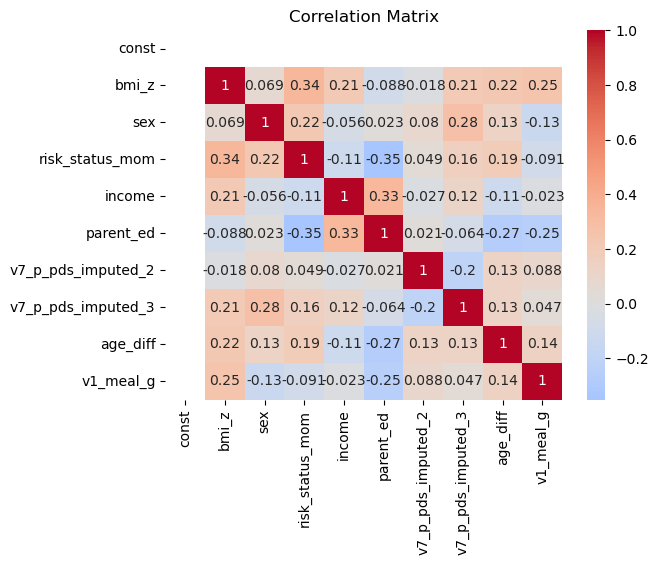

             Variable        VIF
0               const  18.522873
1               bmi_z   1.431626
2                 sex   1.194250
3     risk_status_mom   1.493831
4              income   1.253342
5           parent_ed   1.486079
6  v7_p_pds_imputed_2   1.121697
7  v7_p_pds_imputed_3   1.234629
8            age_diff   1.183437
9           v1_meal_g   1.292539
CHECKING FOR HETEROSKEDASTICITY


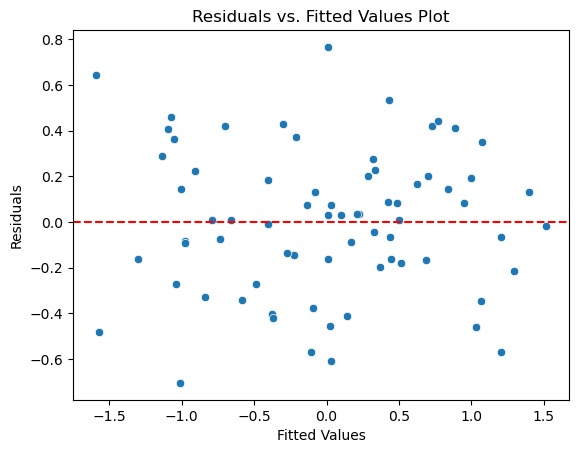

NORMALITY


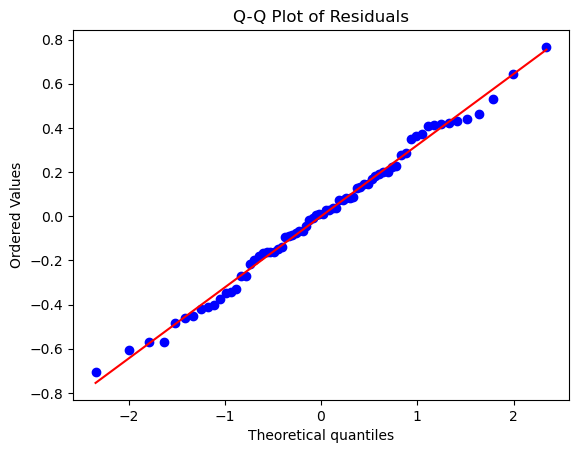

Shapiro-Wilk Test Results:
Statistic: 0.9913949966430664
p-value: 0.9089605212211609
Residuals are normally distributed (fail to reject null hypothesis)


In [99]:
# checking for model assumptions
# Calculate the residuals
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
residuals_mealgBMIz= mod_mealgBMIz.resid

# 1. Linearity
# partial regression plots - refer later

# 2. Multicollinearity
print("MULTICOLLINEARITY and AUTOCORRELATION")
dw_statistic_mealgBMIz = durbin_watson(residuals_mealgBMIz)
print("Durbin-Watson Statistic:", dw_statistic_mealgBMIz)
if 0 < dw_statistic_mealgBMIz < 4:
    print("The Durbin-Watson statistic suggests no significant autocorrelation.")
else:
    print("The Durbin-Watson statistic indicates potential autocorrelation.")

correlation_matrix = X_mealgBMIz.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_mealgBMIz.columns
vif_data["VIF"] = [variance_inflation_factor(X_mealgBMIz.values, i) for i in range(X_mealgBMIz.shape[1])]
print(vif_data)

# 3. Heteroskedasticity Assumption
print("CHECKING FOR HETEROSKEDASTICITY")
sns.scatterplot(x=mod_mealgBMIz.fittedvalues, y=residuals_mealgBMIz)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values Plot")
plt.show()
    
# 4. Normal Distribution of Error Terms Assumption
# Create a Q-Q plot
print("NORMALITY")
stats.probplot(residuals_mealgBMIz, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Perform Shapiro-Wilk test for normality
statistic_mealgBMIz, p_value_mealgBMIz = shapiro(residuals_mealgBMIz)

# Print the test results
print("Shapiro-Wilk Test Results:")
print("Statistic:", statistic_mealgBMIz)
print("p-value:", p_value_mealgBMIz)

# Check the p-value to determine whether residuals are normally distributed
alpha = 0.05  # Significance level
if p_value_mealgBMIz > alpha:
    print("Residuals are normally distributed (fail to reject null hypothesis)")
else:
    print("Residuals are not normally distributed (reject null hypothesis)")

### Model : EAH (gram) at baseline (V1) vs V7 follow-up weight status BMIz (v7)
#### covariates : baseline BMIz, sex, risk status based on maternal weight, tanner stage category at baseline, parent education, parent yearly income, main predictor: baseline EAH intake (gram)

In [100]:
# Select specific columns as predictors (X) and response (y)
X_EAHgBMIz = df_linear_reg[['bmi_z','sex', 'risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff', 'v1_eah_g']]
y_EAHgBMIz = df_linear_reg['v7_bmi_z']

# Add a constant term to the predictors (intercept)
X_EAHgBMIz= sm.add_constant(X_EAHgBMIz)

# Fit a linear regression model using ols
mod_EAHgBMIz= sm.OLS(y_EAHgBMIz, X_EAHgBMIz).fit()

# Get summary of the regression model
print(mod_EAHgBMIz.summary())

                            OLS Regression Results                            
Dep. Variable:               v7_bmi_z   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     40.98
Date:                Thu, 14 Dec 2023   Prob (F-statistic):           8.57e-23
Time:                        23:24:50   Log-Likelihood:                -18.487
No. Observations:                  72   AIC:                             56.97
Df Residuals:                      62   BIC:                             79.74
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.4702      0

### Model : EAH sweet (gram) at baseline (V1) vs V7 follow-up weight status BMIz (v7)
#### covariates : baseline BMIz, sex, risk status based on maternal weight, tanner stage category at baseline, parent education, parent yearly income, main predictor: baseline EAH sweet intake (gram)

In [101]:
# Select specific columns as predictors (X) and response (y)
X_EAHsweetgBMIz = df_linear_reg[['bmi_z','sex', 'risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff', 'v1_eah_sweet_g']]
y_EAHsweetgBMIz = df_linear_reg['v7_bmi_z']

# Add a constant term to the predictors (intercept)
X_EAHsweetgBMIz= sm.add_constant(X_EAHsweetgBMIz)

# Fit a linear regression model using ols
mod_EAHsweetgBMIz= sm.OLS(y_EAHsweetgBMIz, X_EAHsweetgBMIz).fit()

# Get summary of the regression model
print(mod_EAHsweetgBMIz.summary())

                            OLS Regression Results                            
Dep. Variable:               v7_bmi_z   R-squared:                       0.857
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     41.40
Date:                Thu, 14 Dec 2023   Prob (F-statistic):           6.57e-23
Time:                        23:27:30   Log-Likelihood:                -18.172
No. Observations:                  72   AIC:                             56.34
Df Residuals:                      62   BIC:                             79.11
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.4616      0

MULTICOLLINEARITY and AUTOCORRELATION
Durbin-Watson Statistic: 1.7819207304006623
The Durbin-Watson statistic suggests no significant autocorrelation.


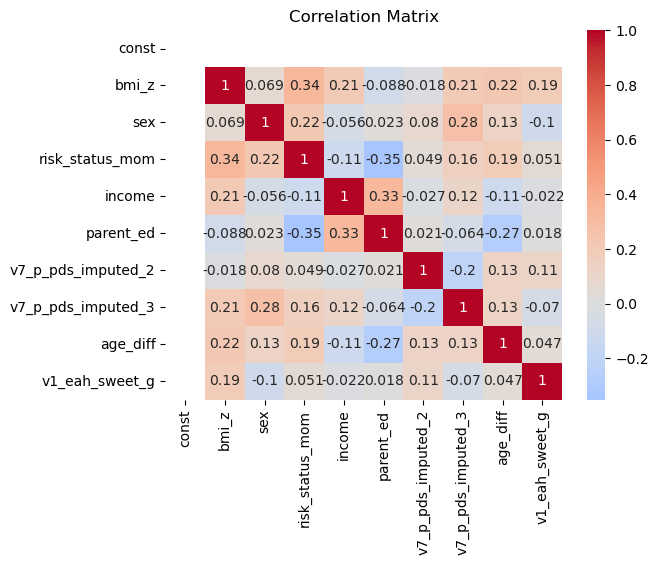

             Variable        VIF
0               const  17.083131
1               bmi_z   1.345262
2                 sex   1.194023
3     risk_status_mom   1.367556
4              income   1.260747
5           parent_ed   1.365593
6  v7_p_pds_imputed_2   1.110645
7  v7_p_pds_imputed_3   1.231395
8            age_diff   1.182870
9      v1_eah_sweet_g   1.081351
CHECKING FOR HETEROSKEDASTICITY


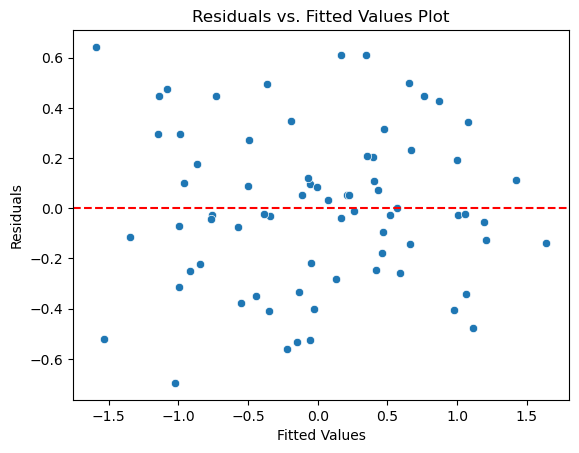

NORMALITY


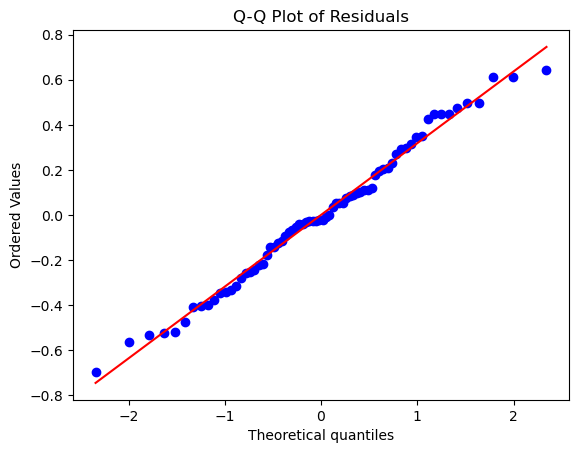

Shapiro-Wilk Test Results:
Statistic: 0.9853422045707703
p-value: 0.5691685080528259
Residuals are normally distributed (fail to reject null hypothesis)


In [102]:
# checking for model assumptions
# Calculate the residuals
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
residuals_EAHsweetgBMIz= mod_EAHsweetgBMIz.resid

# 1. Linearity
# partial regression plots - refer later

# 2. Multicollinearity
print("MULTICOLLINEARITY and AUTOCORRELATION")
dw_statistic_EAHsweetgBMIz = durbin_watson(residuals_EAHsweetgBMIz)
print("Durbin-Watson Statistic:", dw_statistic_EAHsweetgBMIz)
if 0 < dw_statistic_EAHsweetgBMIz < 4:
    print("The Durbin-Watson statistic suggests no significant autocorrelation.")
else:
    print("The Durbin-Watson statistic indicates potential autocorrelation.")

correlation_matrix = X_EAHsweetgBMIz.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_EAHsweetgBMIz.columns
vif_data["VIF"] = [variance_inflation_factor(X_EAHsweetgBMIz.values, i) for i in range(X_EAHsweetgBMIz.shape[1])]
print(vif_data)

# 3. Heteroskedasticity Assumption
print("CHECKING FOR HETEROSKEDASTICITY")
sns.scatterplot(x=mod_EAHsweetgBMIz.fittedvalues, y=residuals_EAHsweetgBMIz)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values Plot")
plt.show()
    
# 4. Normal Distribution of Error Terms Assumption
# Create a Q-Q plot
print("NORMALITY")
stats.probplot(residuals_EAHsweetgBMIz, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Perform Shapiro-Wilk test for normality
statistic_EAHsweetgBMIz, p_value_EAHsweetgBMIz = shapiro(residuals_EAHsweetgBMIz)

# Print the test results
print("Shapiro-Wilk Test Results:")
print("Statistic:", statistic_EAHsweetgBMIz)
print("p-value:", p_value_EAHsweetgBMIz)

# Check the p-value to determine whether residuals are normally distributed
alpha = 0.05  # Significance level
if p_value_EAHsweetgBMIz > alpha:
    print("Residuals are normally distributed (fail to reject null hypothesis)")
else:
    print("Residuals are not normally distributed (reject null hypothesis)")

### Model : EAH savory (gram) at baseline (V1) vs V7 follow-up weight status BMIz (v7)
#### covariates : baseline BMIz, sex, risk status based on maternal weight, tanner stage category at baseline, parent education, parent yearly income, main predictor: baseline EAH savory intake (gram)

In [103]:
# Select specific columns as predictors (X) and response (y)
X_EAHsavgBMIz = df_linear_reg[['bmi_z','sex', 'risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff', 'v1_eah_sav_g']]
y_EAHsavgBMIz = df_linear_reg['v7_bmi_z']

# Add a constant term to the predictors (intercept)
X_EAHsavgBMIz= sm.add_constant(X_EAHsavgBMIz)

# Fit a linear regression model using ols
mod_EAHsavgBMIz= sm.OLS(y_EAHsavgBMIz, X_EAHsavgBMIz).fit()

# Get summary of the regression model
print(mod_EAHsavgBMIz.summary())

                            OLS Regression Results                            
Dep. Variable:               v7_bmi_z   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     39.60
Date:                Thu, 14 Dec 2023   Prob (F-statistic):           2.09e-22
Time:                        23:27:45   Log-Likelihood:                -19.542
No. Observations:                  72   AIC:                             59.08
Df Residuals:                      62   BIC:                             81.85
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.4736      0

MULTICOLLINEARITY and AUTOCORRELATION
Durbin-Watson Statistic: 1.9094296909337087
The Durbin-Watson statistic suggests no significant autocorrelation.


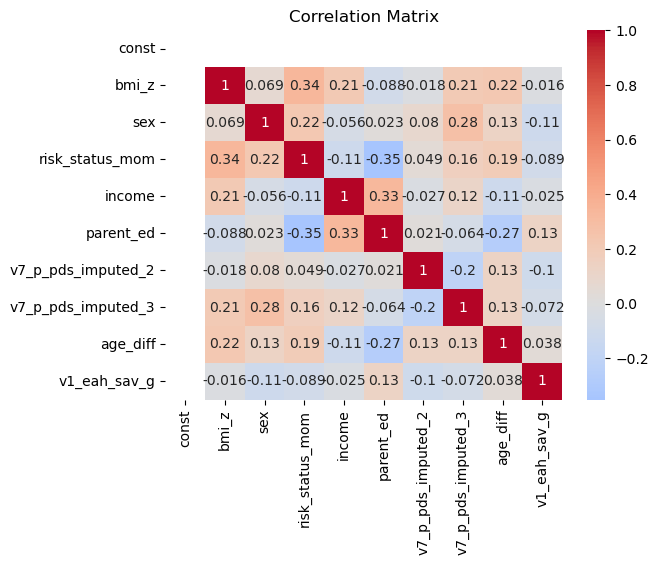

             Variable        VIF
0               const  17.045580
1               bmi_z   1.290338
2                 sex   1.188349
3     risk_status_mom   1.367832
4              income   1.258839
5           parent_ed   1.393944
6  v7_p_pds_imputed_2   1.114630
7  v7_p_pds_imputed_3   1.232938
8            age_diff   1.196929
9        v1_eah_sav_g   1.063371
CHECKING FOR HETEROSKEDASTICITY


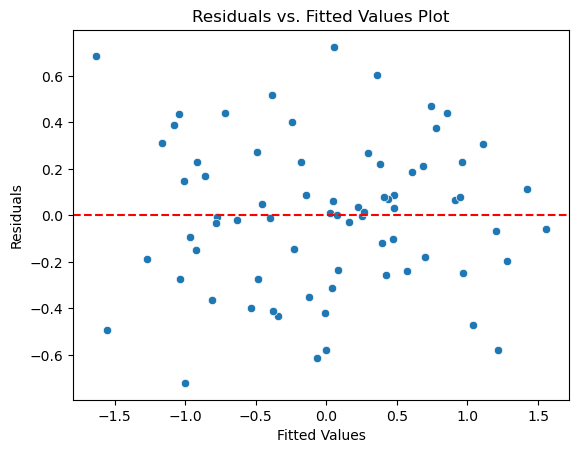

NORMALITY


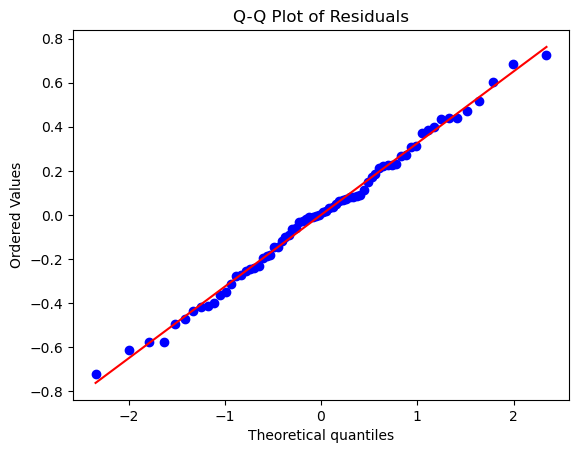

Shapiro-Wilk Test Results:
Statistic: 0.9922624826431274
p-value: 0.9413054585456848
Residuals are normally distributed (fail to reject null hypothesis)


In [105]:
# checking for model assumptions
# Calculate the residuals
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
residuals_EAHsavgBMIz= mod_EAHsavgBMIz.resid

# 1. Linearity
# partial regression plots - refer later

# 2. Multicollinearity
print("MULTICOLLINEARITY and AUTOCORRELATION")
dw_statistic_EAHsavgBMIz = durbin_watson(residuals_EAHsavgBMIz)
print("Durbin-Watson Statistic:", dw_statistic_EAHsavgBMIz)
if 0 < dw_statistic_EAHsavgBMIz< 4:
    print("The Durbin-Watson statistic suggests no significant autocorrelation.")
else:
    print("The Durbin-Watson statistic indicates potential autocorrelation.")

correlation_matrix = X_EAHsavgBMIz.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


# Calculate VIF for each predictor variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_EAHsavgBMIz.columns
vif_data["VIF"] = [variance_inflation_factor(X_EAHsavgBMIz.values, i) for i in range(X_EAHsavgBMIz.shape[1])]
print(vif_data)

# 3. Heteroskedasticity Assumption
print("CHECKING FOR HETEROSKEDASTICITY")
sns.scatterplot(x=mod_EAHsavgBMIz.fittedvalues, y=residuals_EAHsavgBMIz)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values Plot")
plt.show()


# 4. Normal Distribution of Error Terms Assumption
# Create a Q-Q plot
print("NORMALITY")
stats.probplot(residuals_EAHsavgBMIz, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Perform Shapiro-Wilk test for normality
statistic_EAHsavgBMIz, p_value_EAHsavgBMIz = shapiro(residuals_EAHsavgBMIz)

# Print the test results
print("Shapiro-Wilk Test Results:")
print("Statistic:", statistic_EAHsavgBMIz)
print("p-value:", p_value_EAHsavgBMIz)

# Check the p-value to determine whether residuals are normally distributed
alpha = 0.05  # Significance level
if p_value_EAHsavgBMIz > alpha:
    print("Residuals are normally distributed (fail to reject null hypothesis)")
else:
    print("Residuals are not normally distributed (reject null hypothesis)")

## Partial Regression Plots: Baseline Intake (kcal) vs Follow-up adiposity (FMI)

In [109]:
import pandas as pd
from statsmodels.api import OLS
from sklearn.preprocessing import StandardScaler

# I assume you've already loaded df and df_linear_reg, and run OLS models on df_linear_reg

# Extract standard deviations from original dataframe
sd_FMI = df['v7_FMI'].std()
sd_meal_kcal = df['v1_meal_kcal'].std()
sd_eah_kcal = df['v1_eah_kcal'].std()
sd_eah_sweet_kcal = df['v1_eah_sweet_kcal'].std()
sd_eah_sav_kcal = df['v1_eah_sav_kcal'].std()

# define a function to compute the change in FMI for a 100 kcal increase
def change_in_FMI_for_100kcal_increase(coef, sd_FMI, sd_predictor):
    return coef * sd_FMI * (100/sd_predictor)

# Extract coefficients from the models
# Assuming each model has only one predictor, the coefficient will be for that predictor
coef_meal_fmi_kcal = mod_mealkcalFMI.params['v1_meal_kcal']
coef_eah_fmi_kcal = mod_EAHkcalFMI.params['v1_eah_kcal']
coef_eah_sweet_fmi_kcal = mod_EAHsweetkcalFMI.params['v1_eah_sweet_kcal']
coef_eah_sav_fmi_kcal = mod_EAHsavkcalFMI.params['v1_eah_sav_kcal']

# Calculate the change in FMI for a 100 kcal increase
change_meal_fmi_kcal = change_in_FMI_for_100kcal_increase(coef_meal_fmi_kcal, sd_FMI, sd_meal_kcal)
change_eah_fmi_kcal = change_in_FMI_for_100kcal_increase(coef_eah_fmi_kcal, sd_FMI, sd_eah_kcal)
change_eah_sweet_fmi_kcal = change_in_FMI_for_100kcal_increase(coef_eah_sweet_fmi_kcal, sd_FMI, sd_eah_sweet_kcal)
change_eah_sav_fmi_kcal= change_in_FMI_for_100kcal_increase(coef_eah_sav_fmi_kcal, sd_FMI, sd_eah_sav_kcal)

print("Change in FMI for 100 kcal increase in:")
print("Meal kcal:", change_meal_fmi_kcal)
print("EAH kcal:", change_eah_fmi_kcal)
print("EAH sweet kcal:", change_eah_sweet_fmi_kcal)
print("EAH sav kcal:", change_eah_sav_fmi_kcal)

Change in FMI for 100 kcal increase in:
Meal kcal: -0.007905499313211177
EAH kcal: 0.12824614725659972
EAH sweet kcal: 0.1290923362112229
EAH sav kcal: 0.11057927113739274


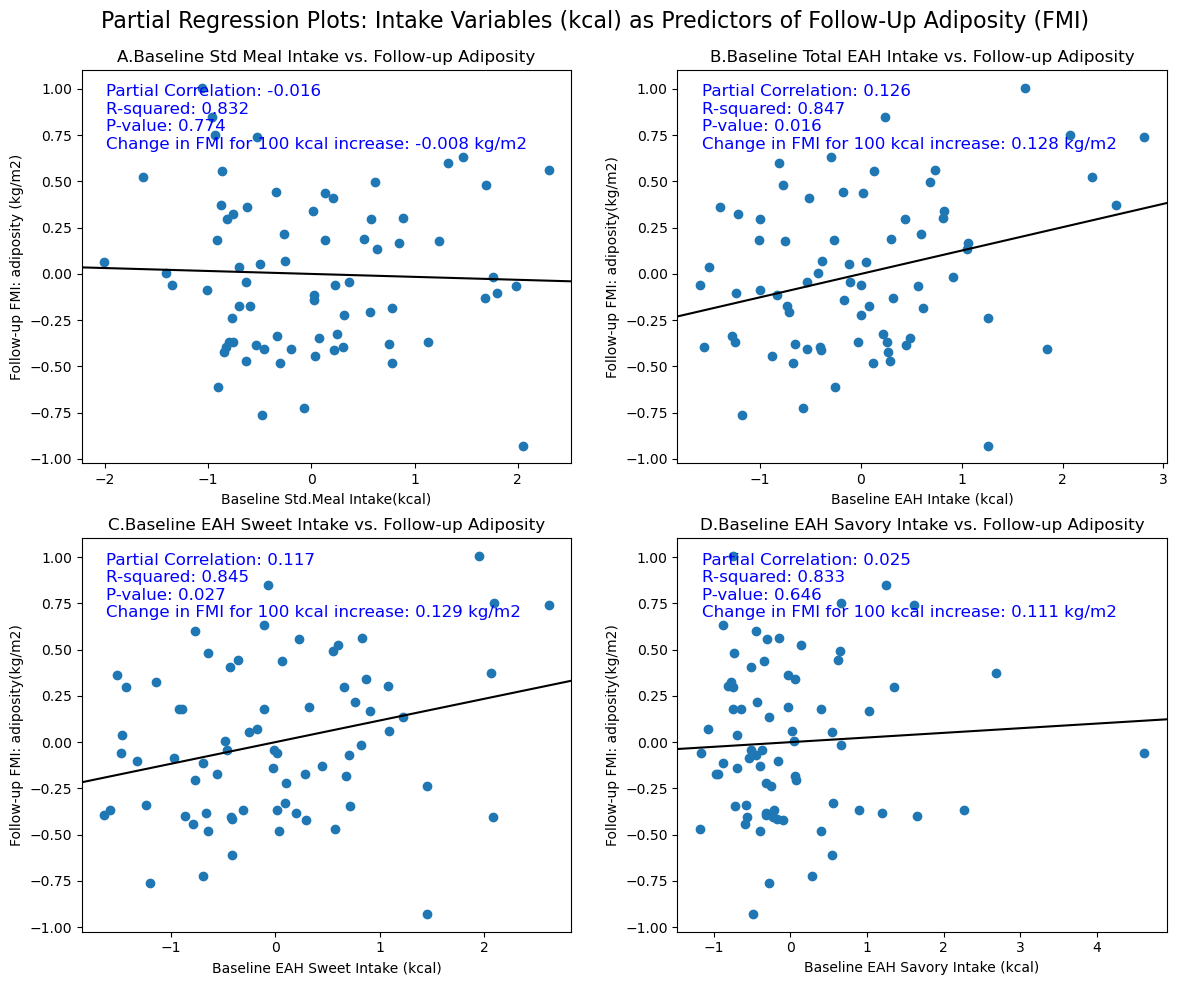

In [110]:
# partial reg plots (intake kcal vs v7_FMI)
# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Partial regression meal (kcal) vs FMI
plot1 = sm.graphics.plot_partregress('v7_FMI', 'v1_meal_kcal', ['v1_FMI','sex','risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff'], data=df_linear_reg, obs_labels=False, ax=axes[0, 0])
axes[0, 0].set_xlabel("Baseline Std.Meal Intake(kcal)")
axes[0, 0].set_ylabel("Follow-up FMI: adiposity (kg/m2)")
axes[0, 0].set_title("A.Baseline Std Meal Intake vs. Follow-up Adiposity")
axes[0, 0].annotate(f"Partial Correlation: {mod_mealkcalFMI.params['v1_meal_kcal']:.3f}\nR-squared: {mod_mealkcalFMI.rsquared:.3f}\nP-value: {mod_mealkcalFMI.pvalues['v1_meal_kcal']:.3f}\nChange in FMI for 100 kcal increase: {change_meal_fmi_kcal:.3f} kg/m2", xy=(0.05, 0.8), xycoords='axes fraction', fontsize=12, color='blue')

# Partial regression EAH total (kcal) vs FMI
plot2 = sm.graphics.plot_partregress('v7_FMI', 'v1_eah_kcal', ['v1_FMI', 'sex','risk_status_mom', 'income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff'], data=df_linear_reg, obs_labels=False, ax=axes[0, 1])
axes[0, 1].set_xlabel("Baseline EAH Intake (kcal)")
axes[0, 1].set_ylabel("Follow-up FMI: adiposity(kg/m2)")
axes[0, 1].set_title("B.Baseline Total EAH Intake vs. Follow-up Adiposity")
axes[0, 1].annotate(f"Partial Correlation: {mod_EAHkcalFMI.params['v1_eah_kcal']:.3f}\nR-squared: {mod_EAHkcalFMI.rsquared:.3f}\nP-value: {mod_EAHkcalFMI.pvalues['v1_eah_kcal']:.3f}\nChange in FMI for 100 kcal increase: {change_eah_fmi_kcal:.3f} kg/m2", xy=(0.05, 0.8), xycoords='axes fraction', fontsize=12, color='blue')

# Partial regression EAH sweet (kcal) vs FMI
sm.graphics.plot_partregress('v7_FMI', 'v1_eah_sweet_kcal', ['v1_FMI', 'sex','risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff'], data=df_linear_reg, obs_labels=False, ax=axes[1, 0])
axes[1, 0].set_xlabel("Baseline EAH Sweet Intake (kcal)")
axes[1, 0].set_ylabel("Follow-up FMI: adiposity(kg/m2)")
axes[1, 0].set_title("C.Baseline EAH Sweet Intake vs. Follow-up Adiposity")
axes[1, 0].annotate(f"Partial Correlation: {mod_EAHsweetkcalFMI.params['v1_eah_sweet_kcal']:.3f}\nR-squared: {mod_EAHsweetkcalFMI.rsquared:.3f}\nP-value: {mod_EAHsweetkcalFMI.pvalues['v1_eah_sweet_kcal']:.3f}\nChange in FMI for 100 kcal increase: {change_eah_sweet_fmi_kcal:.3f} kg/m2", xy=(0.05, 0.8), xycoords='axes fraction', fontsize=12, color='blue')

# Partial regression EAH savory (kcal) vs FMI
sm.graphics.plot_partregress('v7_FMI', 'v1_eah_sav_kcal', ['v1_FMI', 'sex','risk_status_mom', 'income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff'], data=df_linear_reg, obs_labels=False, ax=axes[1, 1])
axes[1, 1].set_xlabel("Baseline EAH Savory Intake (kcal)")
axes[1, 1].set_ylabel("Follow-up FMI: adiposity(kg/m2)")
axes[1, 1].set_title("D.Baseline EAH Savory Intake vs. Follow-up Adiposity")
axes[1, 1].annotate(f"Partial Correlation: {mod_EAHsavkcalFMI.params['v1_eah_sav_kcal']:.3f}\nR-squared: {mod_EAHsavkcalFMI.rsquared:.3f}\nP-value: {mod_EAHsavkcalFMI.pvalues['v1_eah_sav_kcal']:.3f}\nChange in FMI for 100 kcal increase: {change_eah_sav_fmi_kcal:.3f} kg/m2", xy=(0.05, 0.8), xycoords='axes fraction', fontsize=12, color='blue')

fig.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle(
    "Partial Regression Plots: Intake Variables (kcal) as Predictors of Follow-Up Adiposity (FMI)", fontsize=16)
plt.show()

## Partial Regression Plots: Baseline Intake (kcal) vs Follow-up weight status (BMIz)

In [111]:
# Extract the standard deviation only for predictor variables
sd_meal_kcal = df['v1_meal_kcal'].std()
sd_eah_kcal = df['v1_eah_kcal'].std()
sd_eah_sweet_kcal = df['v1_eah_sweet_kcal'].std()
sd_eah_sav_kcal = df['v1_eah_sav_kcal'].std()

# modify the function to compute the change in v7_bmi_z for a 100 kcal increase
def change_in_bmi_z_for_100kcal_increase(coef, sd_predictor):
    return coef * (100/sd_predictor)

# Extract coefficients from the models
coef_meal_bmi_kcal = mod_mealkcalBMIz.params['v1_meal_kcal']
coef_eah_bmi_kcal = mod_EAHkcalBMIz.params['v1_eah_kcal']
coef_eah_sweet_bmi_kcal = mod_EAHsweetkcalBMIz.params['v1_eah_sweet_kcal']
coef_eah_sav_bmi_kcal = mod_EAHsavkcalBMIz.params['v1_eah_sav_kcal']

# Calculate the change in v7_bmi_z for a 100 kcal increase
change_meal_bmi_kcal = change_in_bmi_z_for_100kcal_increase(coef_meal_bmi_kcal, sd_meal_kcal)
change_eah_bmi_kcal = change_in_bmi_z_for_100kcal_increase(coef_eah_bmi_kcal, sd_eah_kcal)
change_eah_sweet_bmi_kcal = change_in_bmi_z_for_100kcal_increase(coef_eah_sweet_bmi_kcal, sd_eah_sweet_kcal)
change_eah_sav_bmi_kcal = change_in_bmi_z_for_100kcal_increase(coef_eah_sav_bmi_kcal, sd_eah_sav_kcal)

print("Change in v7_bmi_z for 100 kcal increase in:")
print("Meal kcal:", change_meal_bmi_kcal)
print("EAH kcal:", change_eah_bmi_kcal)
print("EAH sweet kcal:", change_eah_sweet_bmi_kcal)
print("EAH sav kcal:", change_eah_sav_bmi_kcal)

Change in v7_bmi_z for 100 kcal increase in:
Meal kcal: 0.014815700633449922
EAH kcal: 0.0370749924252666
EAH sweet kcal: 0.04604571951765674
EAH sav kcal: 0.04134707669909142


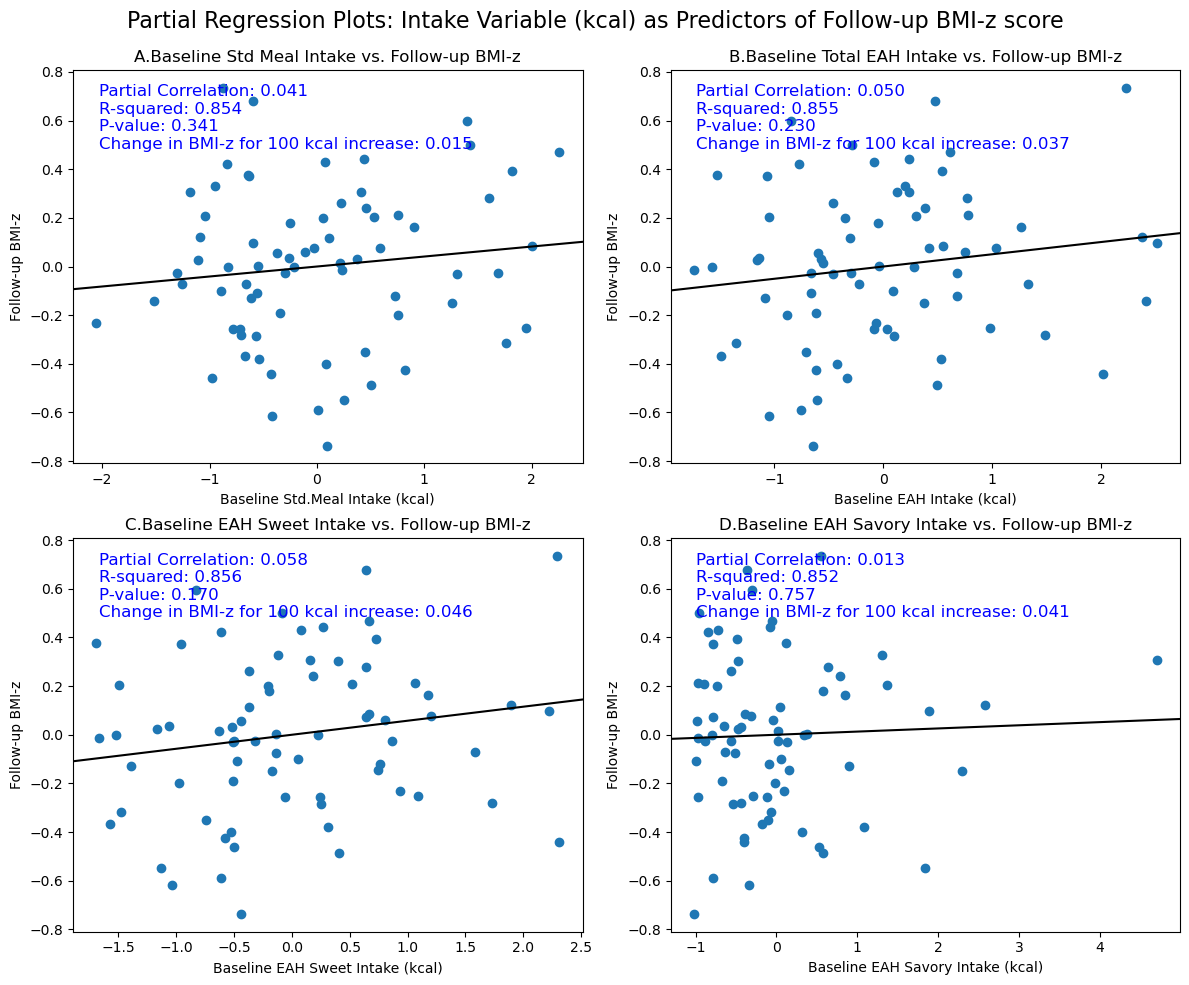

In [112]:
# partial reg plots (intake kcal vs v7_BMIz)
# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Partial regression meal (kcal) vs BMIz
plot1 = sm.graphics.plot_partregress('v7_bmi_z', 'v1_meal_kcal', ['bmi_z','sex','risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff'], data=df_linear_reg, obs_labels=False, ax=axes[0, 0])
axes[0, 0].set_xlabel("Baseline Std.Meal Intake (kcal)")
axes[0, 0].set_ylabel("Follow-up BMI-z")
axes[0, 0].set_title("A.Baseline Std Meal Intake vs. Follow-up BMI-z")
axes[0, 0].annotate(f"Partial Correlation: {mod_mealkcalBMIz.params['v1_meal_kcal']:.3f}\nR-squared: {mod_mealkcalBMIz.rsquared:.3f}\nP-value: {mod_mealkcalBMIz.pvalues['v1_meal_kcal']:.3f}\nChange in BMI-z for 100 kcal increase: {change_meal_bmi_kcal:.3f}", xy=(0.05, 0.8), xycoords='axes fraction', fontsize=12, color='blue')

# Partial regression EAH total (kcal) vs BMIz
plot2 = sm.graphics.plot_partregress('v7_bmi_z', 'v1_eah_kcal', ['bmi_z','sex','risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff'],  data=df_linear_reg, obs_labels=False, ax=axes[0, 1])
axes[0, 1].set_xlabel("Baseline EAH Intake (kcal)")
axes[0, 1].set_ylabel("Follow-up BMI-z")
axes[0, 1].set_title("B.Baseline Total EAH Intake vs. Follow-up BMI-z")
axes[0, 1].annotate(f"Partial Correlation: {mod_EAHkcalBMIz.params['v1_eah_kcal']:.3f}\nR-squared: {mod_EAHkcalBMIz.rsquared:.3f}\nP-value: {mod_EAHkcalBMIz.pvalues['v1_eah_kcal']:.3f}\nChange in BMI-z for 100 kcal increase: {change_eah_bmi_kcal:.3f}", xy=(0.05, 0.80), xycoords='axes fraction', fontsize=12, color='blue')

# Partial regression EAH sweet (kcal) vs BMIz
sm.graphics.plot_partregress('v7_bmi_z', 'v1_eah_sweet_kcal', ['bmi_z','sex','risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff'],  data=df_linear_reg, obs_labels=False, ax=axes[1, 0])
axes[1, 0].set_xlabel("Baseline EAH Sweet Intake (kcal)")
axes[1, 0].set_ylabel("Follow-up BMI-z")
axes[1, 0].set_title("C.Baseline EAH Sweet Intake vs. Follow-up BMI-z")
axes[1, 0].annotate(f"Partial Correlation: {mod_EAHsweetkcalBMIz.params['v1_eah_sweet_kcal']:.3f}\nR-squared: {mod_EAHsweetkcalBMIz.rsquared:.3f}\nP-value: {mod_EAHsweetkcalBMIz.pvalues['v1_eah_sweet_kcal']:.3f}\nChange in BMI-z for 100 kcal increase: {change_eah_sweet_bmi_kcal:.3f}", xy=(0.05, 0.80), xycoords='axes fraction', fontsize=12, color='blue')

# Partial regression EAH savory (kcal) vs FMI
sm.graphics.plot_partregress('v7_bmi_z', 'v1_eah_sav_kcal', ['bmi_z','sex','risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff'],  data=df_linear_reg, obs_labels=False, ax=axes[1, 1])
axes[1, 1].set_xlabel("Baseline EAH Savory Intake (kcal)")
axes[1, 1].set_ylabel("Follow-up BMI-z")
axes[1, 1].set_title("D.Baseline EAH Savory Intake vs. Follow-up BMI-z")
axes[1, 1].annotate(f"Partial Correlation: {mod_EAHsavkcalBMIz.params['v1_eah_sav_kcal']:.3f}\nR-squared: {mod_EAHsavkcalBMIz.rsquared:.3f}\nP-value: {mod_EAHsavkcalBMIz.pvalues['v1_eah_sav_kcal']:.3f}\nChange in BMI-z for 100 kcal increase: {change_eah_sav_bmi_kcal:.3f}", xy=(0.05, 0.80), xycoords='axes fraction', fontsize=12, color='blue')

fig.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle("Partial Regression Plots: Intake Variable (kcal) as Predictors of Follow-up BMI-z score", fontsize=16)
plt.show()


## Partial Regression Plots: Baseline Intake (gram) vs Follow-up adiposity (FMI)

In [113]:
import pandas as pd
from statsmodels.api import OLS
from sklearn.preprocessing import StandardScaler

# Extract standard deviations from original dataframe
sd_FMI = df['v7_FMI'].std()
sd_meal_g = df['v1_meal_g'].std()
sd_eah_g = df['v1_eah_g'].std()
sd_eah_sweet_g = df['v1_eah_sweet_g'].std()
sd_eah_sav_g = df['v1_eah_sav_g'].std()

# Function to compute the change in FMI for a 100g increase
def change_in_FMI_for_100g_increase(coef, sd_FMI, sd_predictor):
    return coef * sd_FMI * (100/sd_predictor)

# Extract coefficients from the models
coef_meal_g_fmi = mod_mealgFMI.params['v1_meal_g']  # Assuming the predictors in your models are now the gram columns
coef_eah_g_fmi = mod_EAHgFMI.params['v1_eah_g']
coef_eah_sweet_g_fmi = mod_EAHsweetgFMI.params['v1_eah_sweet_g']
coef_eah_sav_g_fmi = mod_EAHsavgFMI.params['v1_eah_sav_g']

# Calculate the change in FMI for a 100g increase
change_meal_g_fmi = change_in_FMI_for_100g_increase(coef_meal_g_fmi, sd_FMI, sd_meal_g)
change_eah_g_fmi = change_in_FMI_for_100g_increase(coef_eah_g_fmi, sd_FMI, sd_eah_g)
change_eah_sweet_g_fmi = change_in_FMI_for_100g_increase(coef_eah_sweet_g_fmi, sd_FMI, sd_eah_sweet_g)
change_eah_sav_g_fmi = change_in_FMI_for_100g_increase(coef_eah_sav_g_fmi, sd_FMI, sd_eah_sav_g)

print("Change in FMI for 100g increase in:")
print("Meal g:", change_meal_g_fmi)
print("EAH g:", change_eah_g_fmi)
print("EAH sweet g:", change_eah_sweet_g_fmi)
print("EAH sav g:", change_eah_sav_g_fmi)


Change in FMI for 100g increase in:
Meal g: 0.0004050020808560396
EAH g: 0.1636942539999089
EAH sweet g: 0.5833840387553826
EAH sav g: 0.574216493893291


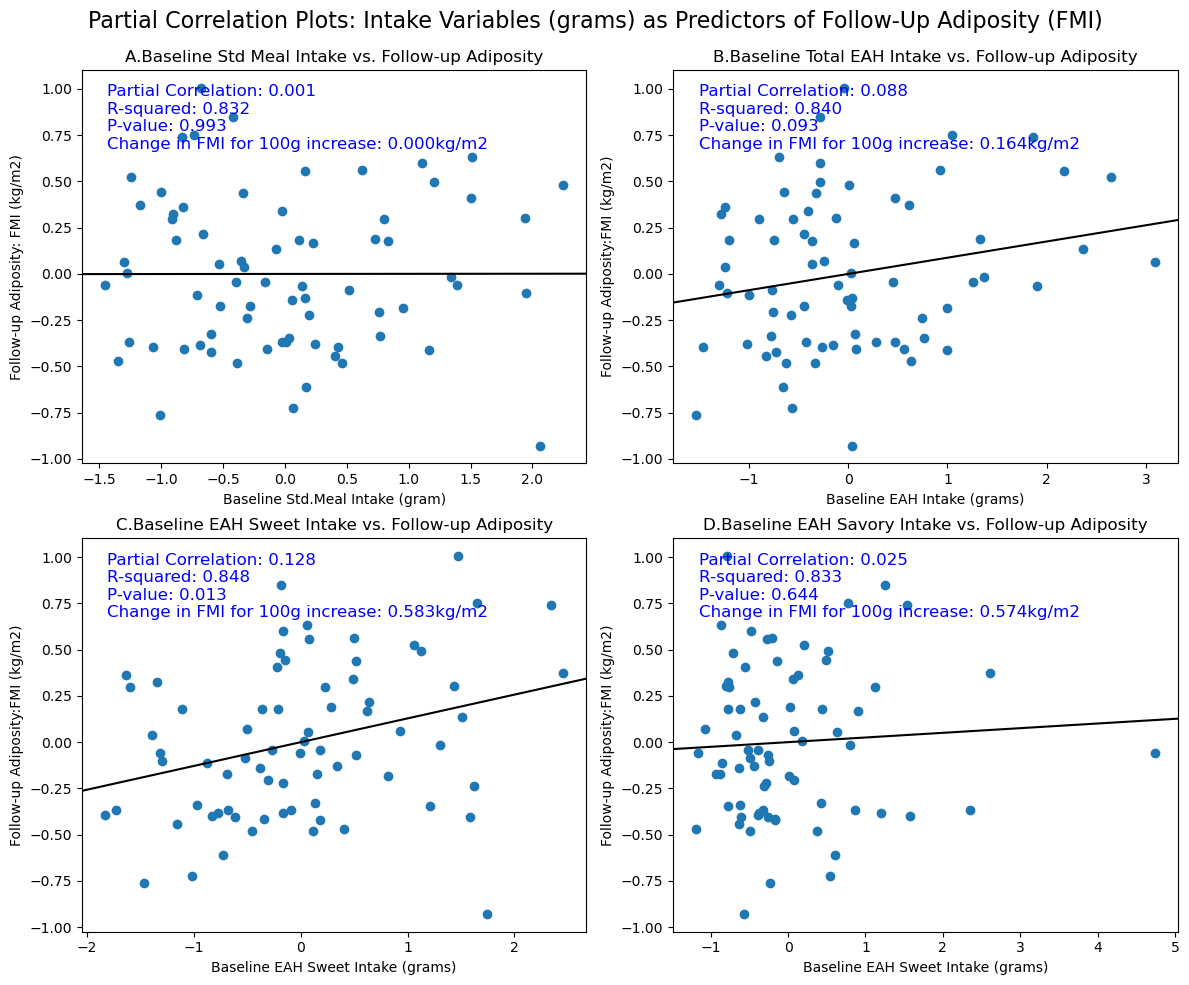

In [114]:
# partial reg plots (intake gram vs v7_FMI)
# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Partial regression meal (g) vs BMIz
plot1 = sm.graphics.plot_partregress('v7_FMI', 'v1_meal_g', ['v1_FMI','sex','risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff'], data=df_linear_reg, obs_labels=False, ax=axes[0, 0])
axes[0, 0].set_xlabel("Baseline Std.Meal Intake (gram)")
axes[0, 0].set_ylabel("Follow-up Adiposity: FMI (kg/m2)")
axes[0, 0].set_title("A.Baseline Std Meal Intake vs. Follow-up Adiposity")
axes[0, 0].annotate(f"Partial Correlation: {mod_mealgFMI.params['v1_meal_g']:.3f}\nR-squared: {mod_mealgFMI.rsquared:.3f}\nP-value: {mod_mealgFMI.pvalues['v1_meal_g']:.3f}\nChange in FMI for 100g increase: {change_meal_g_fmi:.3f}kg/m2", xy=(0.05, 0.80), xycoords='axes fraction', fontsize=12, color='blue')

# Partial regression EAH total (gram) vs FMI
plot2 = sm.graphics.plot_partregress('v7_FMI', 'v1_eah_g', ['v1_FMI','sex','risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff'], data=df_linear_reg, obs_labels=False, ax=axes[0, 1])
axes[0, 1].set_xlabel("Baseline EAH Intake (grams)")
axes[0, 1].set_ylabel("Follow-up Adiposity:FMI (kg/m2)")
axes[0, 1].set_title("B.Baseline Total EAH Intake vs. Follow-up Adiposity")
axes[0, 1].annotate(f"Partial Correlation: {mod_EAHgFMI.params['v1_eah_g']:.3f}\nR-squared: {mod_EAHgFMI.rsquared:.3f}\nP-value: {mod_EAHgFMI.pvalues['v1_eah_g']:.3f}\nChange in FMI for 100g increase: {change_eah_g_fmi:.3f}kg/m2", xy=(
    0.05, 0.80), xycoords='axes fraction', fontsize=12, color='blue')

# Partial regression EAH sweet (gram) vs FMI
sm.graphics.plot_partregress('v7_FMI', 'v1_eah_sweet_g', ['v1_FMI','sex','risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff'], data=df_linear_reg, obs_labels=False, ax=axes[1, 0])
axes[1, 0].set_xlabel("Baseline EAH Sweet Intake (grams)")
axes[1, 0].set_ylabel("Follow-up Adiposity:FMI (kg/m2)")
axes[1, 0].set_title("C.Baseline EAH Sweet Intake vs. Follow-up Adiposity")
axes[1, 0].annotate(f"Partial Correlation: {mod_EAHsweetgFMI.params['v1_eah_sweet_g']:.3f}\nR-squared: {mod_EAHsweetgFMI.rsquared:.3f}\nP-value: {mod_EAHsweetgFMI.pvalues['v1_eah_sweet_g']:.3f}\nChange in FMI for 100g increase: {change_eah_sweet_g_fmi:.3f}kg/m2", xy=(
    0.05, 0.80), xycoords='axes fraction', fontsize=12, color='blue')

# Partial regression EAH savory (gram) vs FMI
sm.graphics.plot_partregress('v7_FMI', 'v1_eah_sav_g', ['v1_FMI','sex','risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff'], data=df_linear_reg, obs_labels=False, ax=axes[1, 1])
axes[1, 1].set_xlabel("Baseline EAH Sweet Intake (grams)")
axes[1, 1].set_ylabel("Follow-up Adiposity:FMI (kg/m2)")
axes[1, 1].set_title("D.Baseline EAH Savory Intake vs. Follow-up Adiposity")
axes[1, 1].annotate(f"Partial Correlation: {mod_EAHsavgFMI.params['v1_eah_sav_g']:.3f}\nR-squared: {mod_EAHsavgFMI.rsquared:.3f}\nP-value: {mod_EAHsavgFMI.pvalues['v1_eah_sav_g']:.3f}\nChange in FMI for 100g increase: {change_eah_sav_g_fmi:.3f}kg/m2", xy=(
    0.05, 0.80), xycoords='axes fraction', fontsize=12, color='blue')

fig.tight_layout()
plt.suptitle(
    "Partial Correlation Plots: Intake Variables (grams) as Predictors of Follow-Up Adiposity (FMI)", fontsize=16)
plt.subplots_adjust(top=0.92)

## Partial Regression Plots: Baseline Intake (gram) vs Follow-up weight status (BMIz)

In [115]:
# Extract the standard deviation only for predictor variables
sd_meal_g = df['v1_meal_g'].std()
sd_eah_g= df['v1_eah_g'].std()
sd_eah_sweet_g = df['v1_eah_sweet_g'].std()
sd_eah_sav_g = df['v1_eah_sav_g'].std()

# modify the function to compute the change in v7_bmi_z for a 100 kcal increase
def change_in_bmi_z_for_100g_increase(coef, sd_predictor):
    return coef * (100/sd_predictor)

# Extract coefficients from the models
coef_meal_bmi_g = mod_mealgBMIz.params['v1_meal_g']
coef_eah_bmi_g = mod_EAHgBMIz.params['v1_eah_g']
coef_eah_sweet_bmi_g = mod_EAHsweetgBMIz.params['v1_eah_sweet_g']
coef_eah_sav_bmi_g = mod_EAHsavgBMIz.params['v1_eah_sav_g']

# Calculate the change in v7_bmi_z for a 100 kcal increase
change_meal_bmi_g = change_in_bmi_z_for_100kcal_increase(coef_meal_bmi_g, sd_meal_g)
change_eah_bmi_g = change_in_bmi_z_for_100kcal_increase(coef_eah_bmi_g, sd_eah_g)
change_eah_sweet_bmi_g = change_in_bmi_z_for_100kcal_increase(coef_eah_sweet_bmi_g, sd_eah_sweet_g)
change_eah_sav_bmi_g = change_in_bmi_z_for_100kcal_increase(coef_eah_sav_bmi_g, sd_eah_sav_g)

print("Change in v7_bmi_z for 100 kcal increase in:")
print("Meal kcal:", change_meal_bmi_g)
print("EAH kcal:", change_eah_bmi_g)
print("EAH sweet kcal:", change_eah_sweet_bmi_g)
print("EAH sav kcal:", change_eah_sav_bmi_g)

Change in v7_bmi_z for 100 kcal increase in:
Meal kcal: 0.02908077456534731
EAH kcal: 0.07671486953178308
EAH sweet kcal: 0.21674077287817445
EAH sav kcal: 0.26754824543081346


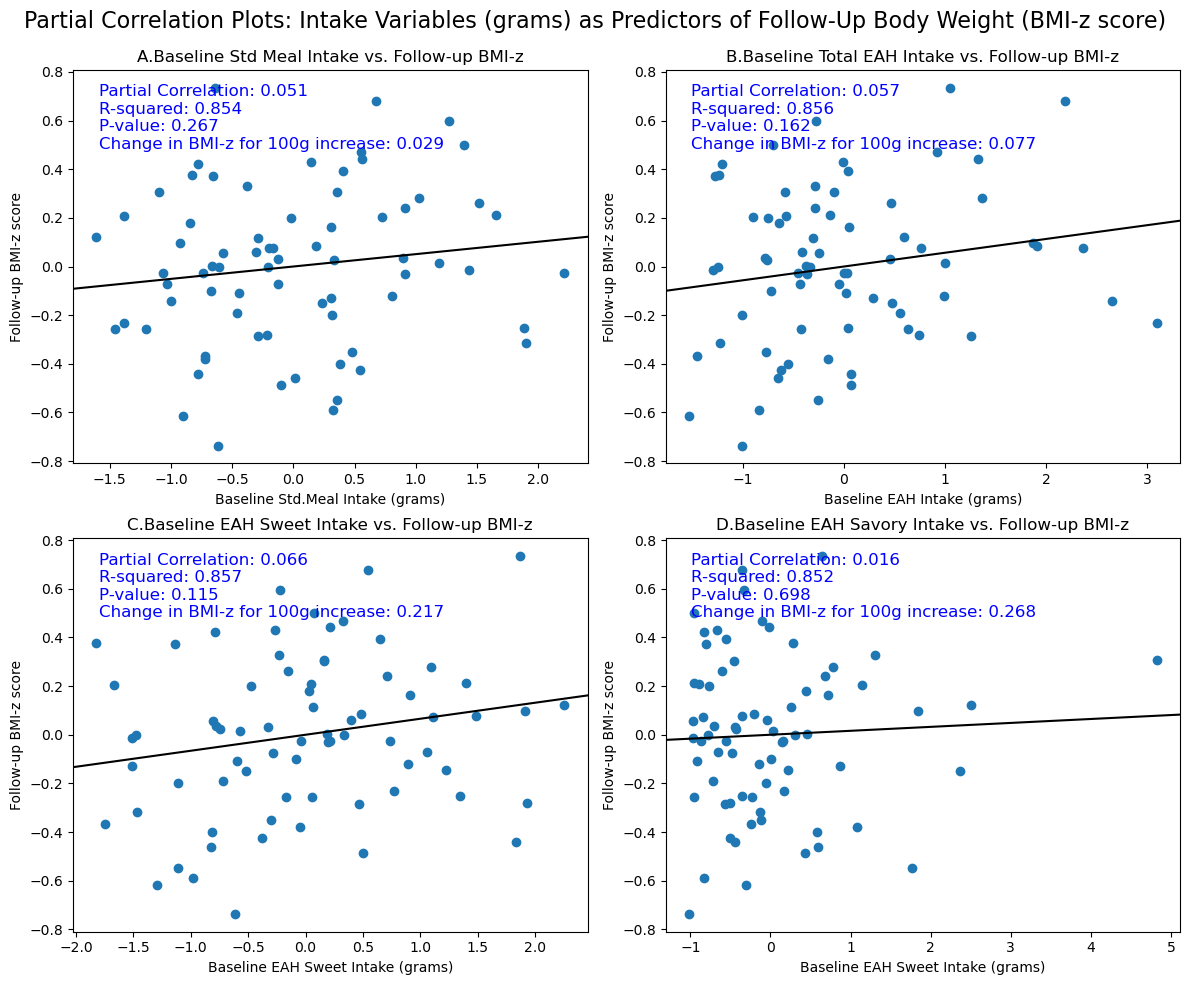

In [116]:
# partial reg plots (intake gram vs v7_bmi_z)
# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Partial regression meal (gram) vs FMI
plot1 = sm.graphics.plot_partregress('v7_bmi_z', 'v1_meal_g', ['bmi_z','sex','risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff'], data=df_linear_reg, obs_labels=False, ax=axes[0, 0])
axes[0, 0].set_xlabel("Baseline Std.Meal Intake (grams)")
axes[0, 0].set_ylabel("Follow-up BMI-z score")
axes[0, 0].set_title("A.Baseline Std Meal Intake vs. Follow-up BMI-z")
axes[0, 0].annotate(f"Partial Correlation: {mod_mealgBMIz.params['v1_meal_g']:.3f}\nR-squared: {mod_mealgBMIz.rsquared:.3f}\nP-value: {mod_mealgBMIz.pvalues['v1_meal_g']:.3f}\nChange in BMI-z for 100g increase: {change_meal_bmi_g:.3f}", xy=(
    0.05, 0.8), xycoords='axes fraction', fontsize=12, color='blue')

# Partial regression EAH total (gram) vs FMI
plot2 = sm.graphics.plot_partregress('v7_bmi_z', 'v1_eah_g', ['bmi_z','sex','risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff'], data=df_linear_reg, obs_labels=False, ax=axes[0, 1])
axes[0, 1].set_xlabel("Baseline EAH Intake (grams)")
axes[0, 1].set_ylabel("Follow-up BMI-z score")
axes[0, 1].set_title("B.Baseline Total EAH Intake vs. Follow-up BMI-z")
axes[0, 1].annotate(f"Partial Correlation: {mod_EAHgBMIz.params['v1_eah_g']:.3f}\nR-squared: {mod_EAHgBMIz.rsquared:.3f}\nP-value: {mod_EAHgBMIz.pvalues['v1_eah_g']:.3f}\nChange in BMI-z for 100g increase: {change_eah_bmi_g:.3f}", xy=(
    0.05, 0.8), xycoords='axes fraction', fontsize=12, color='blue')

# Partial regression EAH sweet (gram) vs FMI
sm.graphics.plot_partregress('v7_bmi_z', 'v1_eah_sweet_g', ['bmi_z','sex','risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff'], data=df_linear_reg, obs_labels=False, ax=axes[1, 0])
axes[1, 0].set_xlabel("Baseline EAH Sweet Intake (grams)")
axes[1, 0].set_ylabel("Follow-up BMI-z score")
axes[1, 0].set_title("C.Baseline EAH Sweet Intake vs. Follow-up BMI-z")
axes[1, 0].annotate(f"Partial Correlation: {mod_EAHsweetgBMIz.params['v1_eah_sweet_g']:.3f}\nR-squared: {mod_EAHsweetgBMIz.rsquared:.3f}\nP-value: {mod_EAHsweetgBMIz.pvalues['v1_eah_sweet_g']:.3f}\nChange in BMI-z for 100g increase: {change_eah_sweet_bmi_g:.3f}", xy=(
    0.05, 0.8), xycoords='axes fraction', fontsize=12, color='blue')

# Partial regression EAH savory (gram) vs FMI
sm.graphics.plot_partregress('v7_bmi_z', 'v1_eah_sav_g', ['bmi_z','sex','risk_status_mom','income','parent_ed','v7_p_pds_imputed_2', 'v7_p_pds_imputed_3','age_diff'], data=df_linear_reg, obs_labels=False, ax=axes[1, 1])
axes[1, 1].set_xlabel("Baseline EAH Sweet Intake (grams)")
axes[1, 1].set_ylabel("Follow-up BMI-z score")
axes[1, 1].set_title("D.Baseline EAH Savory Intake vs. Follow-up BMI-z")
axes[1, 1].annotate(f"Partial Correlation: {mod_EAHsavgBMIz.params['v1_eah_sav_g']:.3f}\nR-squared: {mod_EAHsavgBMIz.rsquared:.3f}\nP-value: {mod_EAHsavgBMIz.pvalues['v1_eah_sav_g']:.3f}\nChange in BMI-z for 100g increase: {change_eah_sav_bmi_g:.3f}", xy=(
    0.05, 0.8), xycoords='axes fraction', fontsize=12, color='blue')

fig.tight_layout()
plt.suptitle("Partial Correlation Plots: Intake Variables (grams) as Predictors of Follow-Up Body Weight (BMI-z score)", fontsize=16)
plt.subplots_adjust(top=0.92)
plt.show()


## Scatterplots for baseline vs follow-up intake measures(kcal)

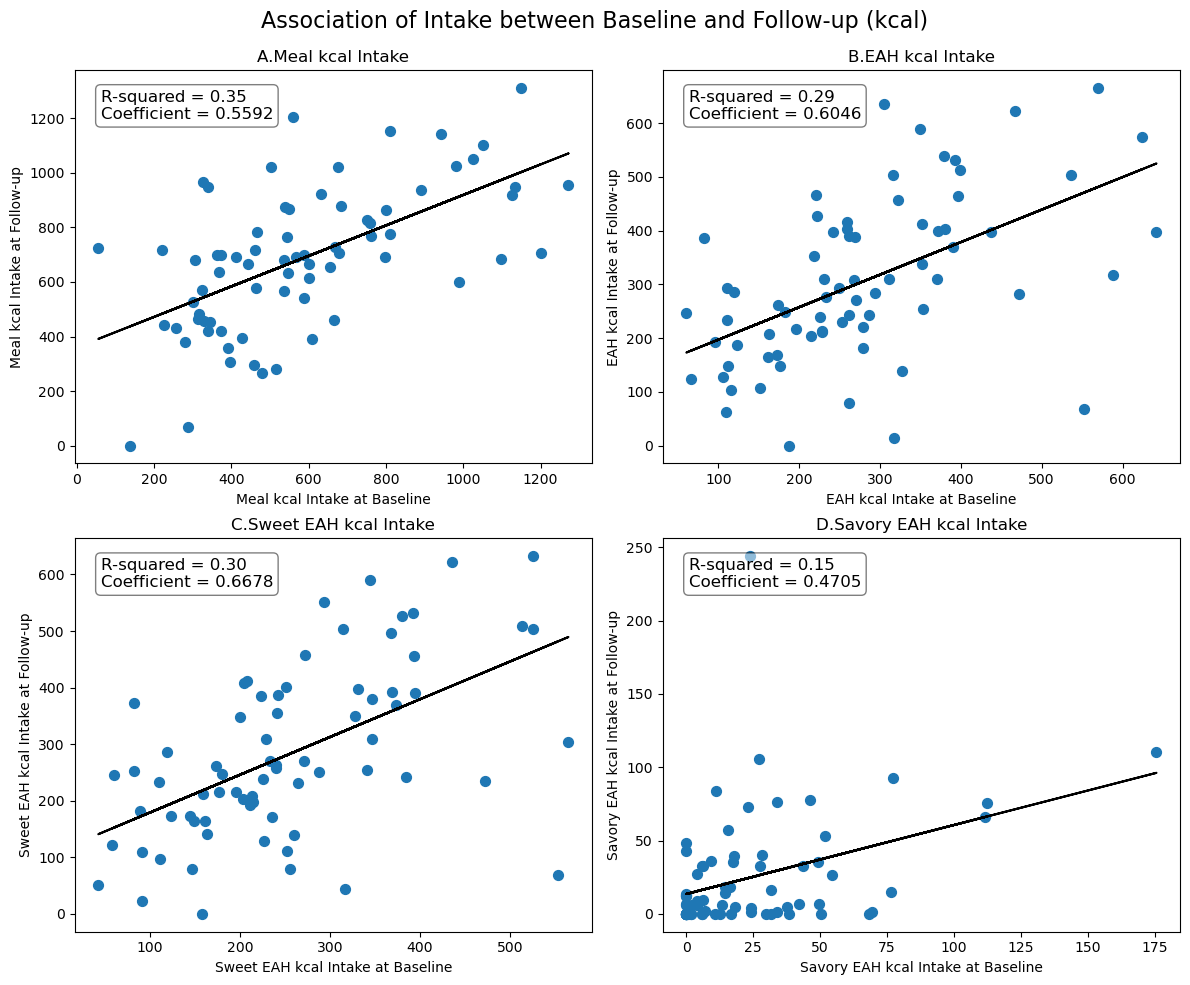

In [117]:
# Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Scatter Plot for Meal Intake
axs[0, 0].scatter(df['v1_meal_kcal'], df['v7_meal_kcal'], s=50)
axs[0, 0].set_xlabel('Meal kcal Intake at Baseline')
axs[0, 0].set_ylabel('Meal kcal Intake at Follow-up')
axs[0, 0].set_title('A.Meal kcal Intake')

# Fit a linear regression model for Meal Intake
x_meal = df['v1_meal_kcal']
y_meal = df['v7_meal_kcal']
coeff_meal = np.polyfit(x_meal, y_meal, 1)
polynomial_meal = np.poly1d(coeff_meal)
correlation_matrix_meal = np.corrcoef(x_meal, y_meal)
correlation_xy_meal = correlation_matrix_meal[0, 1]
r_squared_meal = correlation_xy_meal ** 2
textstr_meal = f'R-squared = {r_squared_meal:.2f}\nCoefficient = {coeff_meal[0]:.4f}'
axs[0, 0].text(0.05, 0.95, textstr_meal, transform=axs[0, 0].transAxes, fontsize=12,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
axs[0, 0].plot(x_meal, polynomial_meal(x_meal), color='black')

# Scatter Plot for EAH Intake
axs[0, 1].scatter(df['v1_eah_kcal'], df['v7_eah_kcal'], s=50)
axs[0, 1].set_xlabel('EAH kcal Intake at Baseline')
axs[0, 1].set_ylabel('EAH kcal Intake at Follow-up')
axs[0, 1].set_title('B.EAH kcal Intake')

# Fit a linear regression model for EAH Intake
x_eah = df['v1_eah_kcal']
y_eah = df['v7_eah_kcal']
coeff_eah = np.polyfit(x_eah, y_eah, 1)
polynomial_eah = np.poly1d(coeff_eah)
correlation_matrix_eah = np.corrcoef(x_eah, y_eah)
correlation_xy_eah = correlation_matrix_eah[0, 1]
r_squared_eah = correlation_xy_eah ** 2
textstr_eah = f'R-squared = {r_squared_eah:.2f}\nCoefficient = {coeff_eah[0]:.4f}'
axs[0, 1].text(0.05, 0.95, textstr_eah, transform=axs[0, 1].transAxes, fontsize=12,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
axs[0, 1].plot(x_eah, polynomial_eah(x_eah), color='black')


# Scatter Plot for Sweet EAH Intake
axs[1, 0].scatter(df['v1_eah_sweet_kcal'], df['v7_eah_sweet_kcal'], s=50)
axs[1, 0].set_xlabel('Sweet EAH kcal Intake at Baseline')
axs[1, 0].set_ylabel('Sweet EAH kcal Intake at Follow-up')
axs[1, 0].set_title('C.Sweet EAH kcal Intake')

# Fit a linear regression model for Sweet EAH Intake
x_sweet = df['v1_eah_sweet_kcal']
y_sweet = df['v7_eah_sweet_kcal']
coeff_sweet = np.polyfit(x_sweet, y_sweet, 1)
polynomial_sweet = np.poly1d(coeff_sweet)
correlation_matrix_sweet = np.corrcoef(x_sweet, y_sweet)
correlation_xy_sweet = correlation_matrix_sweet[0, 1]
r_squared_sweet = correlation_xy_sweet ** 2
textstr_sweet = f'R-squared = {r_squared_sweet:.2f}\nCoefficient = {coeff_sweet[0]:.4f}'
axs[1, 0].text(0.05, 0.95, textstr_sweet, transform=axs[1, 0].transAxes, fontsize=12,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
axs[1, 0].plot(x_sweet, polynomial_sweet(x_sweet), color='black')

# Scatter Plot for Savory EAH Intake
axs[1, 1].scatter(df['v1_eah_sav_kcal'], df['v7_eah_sav_kcal'], s=50)
axs[1, 1].set_xlabel('Savory EAH kcal Intake at Baseline')
axs[1, 1].set_ylabel('Savory EAH kcal Intake at Follow-up')
axs[1, 1].set_title('D.Savory EAH kcal Intake')

# Fit a linear regression model for Savory EAH Intake
x_savory = df['v1_eah_sav_kcal']
y_savory = df['v7_eah_sav_kcal']
coeff_savory = np.polyfit(x_savory, y_savory, 1)
polynomial_savory = np.poly1d(coeff_savory)
correlation_matrix_savory = np.corrcoef(x_savory, y_savory)
correlation_xy_savory = correlation_matrix_savory[0, 1]
r_squared_savory = correlation_xy_savory ** 2
textstr_savory = f'R-squared = {r_squared_savory:.2f}\nCoefficient = {coeff_savory[0]:.4f}'
axs[1, 1].text(0.05, 0.95, textstr_savory, transform=axs[1, 1].transAxes, fontsize=12,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
axs[1, 1].plot(x_savory, polynomial_savory(x_savory), color='black')

plt.tight_layout()
plt.suptitle(
    "Association of Intake between Baseline and Follow-up (kcal)", fontsize=16)
plt.subplots_adjust(top=0.92)
plt.show()

## Scatterplots for baseline vs follow-up intake measures(grams)

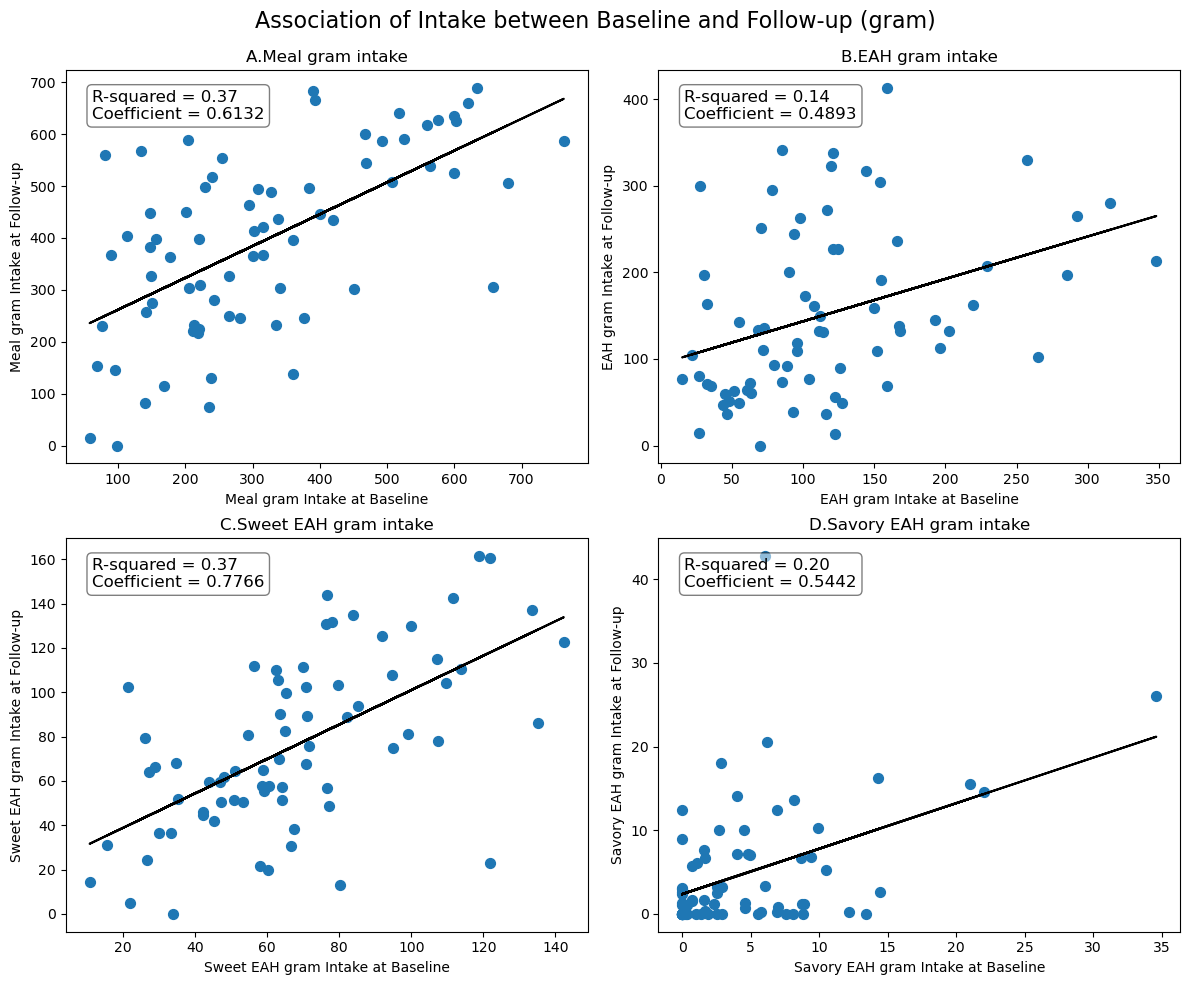

In [118]:
# Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Scatter Plot for Meal Intake
axs[0, 0].scatter(df['v1_meal_g'], df['v7_meal_g'], s=50)
axs[0, 0].set_xlabel('Meal gram Intake at Baseline')
axs[0, 0].set_ylabel('Meal gram Intake at Follow-up')
axs[0, 0].set_title('A.Meal gram intake')

# Fit a linear regression model for Meal Intake
x_meal = df['v1_meal_g']
y_meal = df['v7_meal_g']
coeff_meal = np.polyfit(x_meal, y_meal, 1)
polynomial_meal = np.poly1d(coeff_meal)
correlation_matrix_meal = np.corrcoef(x_meal, y_meal)
correlation_xy_meal = correlation_matrix_meal[0, 1]
r_squared_meal = correlation_xy_meal ** 2
textstr_meal = f'R-squared = {r_squared_meal:.2f}\nCoefficient = {coeff_meal[0]:.4f}'
axs[0, 0].text(0.05, 0.95, textstr_meal, transform=axs[0, 0].transAxes, fontsize=12,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
axs[0, 0].plot(x_meal, polynomial_meal(x_meal), color='black')# Scatter Plot for EAH Intake
axs[0, 1].scatter(df['v1_eah_g'], df['v7_eah_g'], s=50)
axs[0, 1].set_xlabel('EAH gram Intake at Baseline')
axs[0, 1].set_ylabel('EAH gram Intake at Follow-up')
axs[0, 1].set_title('B.EAH gram intake')

# Fit a linear regression model for EAH Intake
x_eah = df['v1_eah_g']
y_eah = df['v7_eah_g']
coeff_eah = np.polyfit(x_eah, y_eah, 1)
polynomial_eah = np.poly1d(coeff_eah)
correlation_matrix_eah = np.corrcoef(x_eah, y_eah)
correlation_xy_eah = correlation_matrix_eah[0, 1]
r_squared_eah = correlation_xy_eah ** 2
textstr_eah = f'R-squared = {r_squared_eah:.2f}\nCoefficient = {coeff_eah[0]:.4f}'
axs[0, 1].text(0.05, 0.95, textstr_eah, transform=axs[0, 1].transAxes, fontsize=12,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
axs[0, 1].plot(x_eah, polynomial_eah(x_eah), color='black')

# Scatter Plot for Sweet EAH Intake
axs[1, 0].scatter(df['v1_eah_sweet_g'], df['v7_eah_sweet_g'], s=50)
axs[1, 0].set_xlabel('Sweet EAH gram Intake at Baseline')
axs[1, 0].set_ylabel('Sweet EAH gram Intake at Follow-up')
axs[1, 0].set_title('C.Sweet EAH gram intake')

# Fit a linear regression model for Sweet EAH Intake
x_sweet = df['v1_eah_sweet_g']
y_sweet = df['v7_eah_sweet_g']
coeff_sweet = np.polyfit(x_sweet, y_sweet, 1)
polynomial_sweet = np.poly1d(coeff_sweet)
correlation_matrix_sweet = np.corrcoef(x_sweet, y_sweet)
correlation_xy_sweet = correlation_matrix_sweet[0, 1]
r_squared_sweet = correlation_xy_sweet ** 2
textstr_sweet = f'R-squared = {r_squared_sweet:.2f}\nCoefficient = {coeff_sweet[0]:.4f}'
axs[1, 0].text(0.05, 0.95, textstr_sweet, transform=axs[1, 0].transAxes, fontsize=12,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
axs[1, 0].plot(x_sweet, polynomial_sweet(x_sweet), color='black')

# Scatter Plot for Savory EAH Intake
axs[1, 1].scatter(df['v1_eah_sav_g'], df['v7_eah_sav_g'], s=50)
axs[1, 1].set_xlabel('Savory EAH gram Intake at Baseline')
axs[1, 1].set_ylabel('Savory EAH gram Intake at Follow-up')
axs[1, 1].set_title('D.Savory EAH gram intake')

# Fit a linear regression model for Savory EAH Intake
x_savory = df['v1_eah_sav_g']
y_savory = df['v7_eah_sav_g']
coeff_savory = np.polyfit(x_savory, y_savory, 1)
polynomial_savory = np.poly1d(coeff_savory)
correlation_matrix_savory = np.corrcoef(x_savory, y_savory)
correlation_xy_savory = correlation_matrix_savory[0, 1]
r_squared_savory = correlation_xy_savory ** 2
textstr_savory = f'R-squared = {r_squared_savory:.2f}\nCoefficient = {coeff_savory[0]:.4f}'
axs[1, 1].text(0.05, 0.95, textstr_savory, transform=axs[1, 1].transAxes, fontsize=12,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
axs[1, 1].plot(x_savory, polynomial_savory(x_savory), color='black')

plt.tight_layout()
plt.suptitle("Association of Intake between Baseline and Follow-up (gram)", fontsize=16)
plt.subplots_adjust(top=0.92)
plt.show()

## DEMOGRAPHIC TABLE - separate for continuous and categorical

In [119]:
# Select categorical and continuous variables
categorical_vars = ['parent_respondent', 'parent_ed', 'income', 'risk_status_mom','sex', 'ethnicity', 'race', 'pds_tanner_cat', 'v7_p_pds_imputed']
continuous_vars = ['age_yr', 'bmi_percentile','bmi_z','v7_age_yr', 'v7_bmi_percentile','v7_bmi_z','age_diff']

# Initialize an empty DataFrame to store the results
categorical_table = pd.DataFrame(columns=['Variable', 'Category', 'Percentage', 'Count'])

# Loop through each categorical column and calculate percentages and counts
for column in categorical_vars:
    counts = df[column].value_counts()
    percentages = counts / counts.sum() * 100
    for category, count, percentage in zip(counts.index, counts, percentages):
        categorical_table = categorical_table.append({
            'Variable': column,
            'Category': category,
            'Percentage': percentage,
            'Count': count
        }, ignore_index=True)

print(categorical_table)
categorical_table.to_excel('cat_table.xlsx',index=False)

             Variable Category  Percentage Count
0   parent_respondent        0   84.722222    61
1   parent_respondent        1   15.277778    11
2           parent_ed        3   44.444444    32
3           parent_ed        4   22.222222    16
4           parent_ed        5   15.277778    11
5           parent_ed        0    9.722222     7
6           parent_ed        1    8.333333     6
7              income        5   37.500000    27
8              income        3   29.166667    21
9              income        4   23.611111    17
10             income        2    6.944444     5
11             income        1    1.388889     1
12             income        0    1.388889     1
13    risk_status_mom        0   59.722222    43
14    risk_status_mom        1   40.277778    29
15                sex        0   51.388889    37
16                sex        1   48.611111    35
17          ethnicity        0  100.000000    72
18               race        0   95.833333    69
19               rac

C:\Users\ybr5070\AppData\Local\Temp\ipykernel_15732\3674879207.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  categorical_table = categorical_table.append({
C:\Users\ybr5070\AppData\Local\Temp\ipykernel_15732\3674879207.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  categorical_table = categorical_table.append({
C:\Users\ybr5070\AppData\Local\Temp\ipykernel_15732\3674879207.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  categorical_table = categorical_table.append({
C:\Users\ybr5070\AppData\Local\Temp\ipykernel_15732\3674879207.py:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  categorical_table = categorical_table.a

In [120]:
# Create a new DataFrame for the continuous table
continuous_table = pd.DataFrame()

# Continuous variables - mean +/- SD and output range
for col in continuous_vars:
    continuous_table[f'{col}_mean'] = [df[col].mean()]
    continuous_table[f'{col}_SD'] = [df[col].std()]
    continuous_table[f'{col}_min'] = [df[col].min()]
    continuous_table[f'{col}_max'] = [df[col].max()]

# Display the continuous table
print("\nContinuous Table:")
print(continuous_table)
continuous_table.to_excel('cont_table.xlsx')


Continuous Table:
   age_yr_mean  age_yr_SD  age_yr_min  age_yr_max  bmi_percentile_mean  \
0      7.83875   0.578441         7.0        8.99            47.657917   

   bmi_percentile_SD  bmi_percentile_min  bmi_percentile_max  bmi_z_mean  \
0          25.134072                3.91               89.49   -0.082361   

   bmi_z_SD  bmi_z_min  bmi_z_max  v7_age_yr_mean  v7_age_yr_SD  \
0  0.746033      -1.76       1.25        9.341667      0.674522   

   v7_age_yr_min  v7_age_yr_max  v7_bmi_percentile_mean  v7_bmi_percentile_SD  \
0           8.35          11.07                    50.3             26.972575   

   v7_bmi_percentile_min  v7_bmi_percentile_max  v7_bmi_z_mean  v7_bmi_z_SD  \
0                   2.02                  93.72       0.003889     0.830344   

   v7_bmi_z_min  v7_bmi_z_max  age_diff_mean  age_diff_SD  age_diff_min  \
0         -2.05          1.53       1.502917     0.404745          1.07   

   age_diff_max  
0          2.77  


In [121]:
intake_vars = ['v1_eah_kcal', 'v7_eah_kcal', 'v1_meal_kcal', 'v7_meal_kcal',
               'v1_eah_g', 'v7_eah_g', 'v1_meal_g', 'v7_meal_g',
               'v1_eah_sweet_kcal', 'v7_eah_sweet_kcal', 'v1_eah_sav_kcal', 'v7_eah_sav_kcal',
               'v1_eah_sweet_g', 'v7_eah_sweet_g', 'v1_eah_sav_g', 'v7_eah_sav_g']

# Initialize an empty DataFrame to store the Intake Table
intake_table = pd.DataFrame(
    columns=['Intake Variable', 'Mean', 'Min', 'Max', 'SD'])

# Function to calculate statistics and append to the intake_table


def add_to_intake_table(column_name, data_column):
    mean_val = data_column.mean()
    min_val = data_column.min()
    max_val = data_column.max()
    sd_val = data_column.std()

    intake_table.loc[len(intake_table)] = [column_name, mean_val, min_val, max_val, sd_val]


# Calculate statistics for intake variables and add to intake_table
for column in intake_vars:
    add_to_intake_table(column, df[column])

print(intake_table)
intake_table.to_excel('intake_table.xlsx', index=False)

      Intake Variable        Mean       Min         Max          SD
0         v1_eah_kcal  278.758411  60.37431   642.05487  135.856969
1         v7_eah_kcal  305.147560   0.00000   665.39691  152.478667
2        v1_meal_kcal  582.737599  55.81334  1272.07870  277.130820
3        v7_meal_kcal  685.868831   0.00000  1311.72059  262.333956
4            v1_eah_g  116.068056  14.81000   348.29000   73.905656
5            v7_eah_g  151.393194   0.00000   412.97000   96.455009
6           v1_meal_g  318.162068  57.82000   762.67000  174.864715
7           v7_meal_g  395.592170   0.00000   689.17000  175.655709
8   v1_eah_sweet_kcal  255.388834  42.74560   564.92261  125.261096
9   v7_eah_sweet_kcal  282.786763   0.00000   632.48842  151.498003
10    v1_eah_sav_kcal   24.106816   0.00000   175.64743   31.368122
11    v7_eah_sav_kcal   24.889241   0.00000   244.01132   38.757012
12     v1_eah_sweet_g   67.753450  10.65000   142.35000   30.371214
13     v7_eah_sweet_g   75.958472   0.00000   16

Intake variables t test

In [122]:
from scipy.stats import ttest_ind

# Filter data for each risk group
low_risk_data = df[df["risk_status_mom"] == 0]
high_risk_data = df[df["risk_status_mom"] == 1]

# List of continuous variables to test
continuous_variables = ["v1_eah_g", "v1_eah_kcal", "v7_eah_g", "v7_eah_kcal", "v1_meal_g", "v1_meal_kcal", "v7_meal_g", "v7_meal_kcal","v1_eah_sweet_g", "v1_eah_sweet_kcal", "v7_eah_sweet_g", "v7_eah_sweet_kcal","v1_eah_sav_g", "v1_eah_sav_kcal", "v7_eah_sav_g", "v7_eah_sav_kcal"]

# Create a DataFrame to store results
results = []

# Loop through each continuous variable
for variable in continuous_variables:
    t_stat, p_value = ttest_ind(low_risk_data[variable], high_risk_data[variable])
    
    result_entry = {
        "Variable": variable,
        "T-statistic": t_stat,
        "P-value": p_value
    }
    
    results.append(result_entry)

# Convert results list to DataFrame
results_df = pd.DataFrame(results)

# Export results to Excel
results_df.to_excel("t_test_eahvsmeal.xlsx", index=False)

In [123]:
import pandas as pd

# Filter data for each risk group
low_risk_data = df[df["risk_status_mom"] == 0]
high_risk_data = df[df["risk_status_mom"] == 1]

# List of continuous variables to calculate statistics for
continuous_variables = [
    "v1_eah_g", "v1_eah_kcal", "v7_eah_g", "v7_eah_kcal",
    "v1_meal_g", "v1_meal_kcal", "v7_meal_g", "v7_meal_kcal",
    "v1_eah_sweet_g", "v1_eah_sweet_kcal", "v7_eah_sweet_g", "v7_eah_sweet_kcal",
    "v1_eah_sav_g", "v1_eah_sav_kcal", "v7_eah_sav_g", "v7_eah_sav_kcal"
]

# Create a DataFrame to store statistics
statistics = []

# Calculate statistics (mean, SD, min, max) for each variable based on risk status
for variable in continuous_variables:
    low_risk_mean = low_risk_data[variable].mean()
    low_risk_sd = low_risk_data[variable].std()
    low_risk_min = low_risk_data[variable].min()
    low_risk_max = low_risk_data[variable].max()

    high_risk_mean = high_risk_data[variable].mean()
    high_risk_sd = high_risk_data[variable].std()
    high_risk_min = high_risk_data[variable].min()
    high_risk_max = high_risk_data[variable].max()

    result_entry = {
        "Variable": variable,
        "Low Risk Mean": low_risk_mean,
        "Low Risk SD": low_risk_sd,
        "Low Risk Min": low_risk_min,
        "Low Risk Max": low_risk_max,
        "High Risk Mean": high_risk_mean,
        "High Risk SD": high_risk_sd,
        "High Risk Min": high_risk_min,
        "High Risk Max": high_risk_max
    }

    statistics.append(result_entry)

# Convert statistics list to DataFrame
statistics_df = pd.DataFrame(statistics)

# Export statistics to Excel
statistics_df.to_excel("statistics_by_risk_status.xlsx", index=False)

### Exporting table with OLS model params

In [124]:
import pandas as pd
import statsmodels.api as sm

# List of model names
model_names = [
    "mod_mealkcalFMI", "mod_EAHkcalFMI", "mod_EAHsweetkcalFMI", "mod_EAHsavkcalFMI",
    "mod_mealkcalBMIz", "mod_EAHkcalBMIz", "mod_EAHsweetkcalBMIz", "mod_EAHsavkcalBMIz",
    "mod_mealgFMI", "mod_EAHgFMI", "mod_EAHsweetgFMI", "mod_EAHsavgFMI",
     "mod_mealgBMIz", "mod_EAHgBMIz", "mod_EAHsweetgBMIz", "mod_EAHsavgBMIz",
]

# List to store model information
model_info = []

# Loop through each model
for model_name in model_names:
    model = globals()[model_name]  # Get the model object using its name
    
    # Extract parameter for the last predictor
    last_predictor = model.params.index[-1]
    last_param = model.params[last_predictor]
    last_se = model.bse[last_predictor] 
    last_p_value = model.pvalues[last_predictor]
    last_t_value = model.tvalues[last_predictor]
    last_conf_int = model.conf_int().loc[last_predictor]

    # Create a dictionary to store information
    model_entry = {
        "Model Name": model_name,
        "Last Predictor": last_predictor,
        "Last Parameter": last_param,
        "SE": last_se,
        "Last P-value": last_p_value,
        "Last T-value": last_t_value,
        "Last CI 95%": last_conf_int
    }

    model_info.append(model_entry)

# Create a DataFrame from the list of model information
models_df = pd.DataFrame(model_info)

models_df.to_excel("regression model results.xlsx",index=False)

In [125]:
import pandas as pd
from scipy.stats import ttest_rel

# Assuming your dataframe is named df
variables_to_compare = [
    ('meal_kcal', 'v1_meal_kcal', 'v7_meal_kcal'),
    ('eah_kcal', 'v1_eah_kcal', 'v7_eah_kcal'),
    ('sweet_kcal', 'v1_eah_sweet_kcal', 'v7_eah_sweet_kcal'),
    ('sav_kcal', 'v1_eah_sav_kcal', 'v7_eah_sav_kcal'),
    ('sav_g', 'v1_eah_sav_g', 'v7_eah_sav_g'),
    ('sweet_g', 'v1_eah_sweet_g', 'v7_eah_sweet_g'),
    ('meal_g', 'v1_meal_g', 'v7_meal_g'),
    ('eah_g', 'v1_eah_g', 'v7_eah_g')
]

# Initialize an empty DataFrame to store the t-test results
ttest_results = pd.DataFrame(columns=['Variable Pair', 'T-Statistic', 'P-Value'])

# Perform paired t-tests for each variable pair
for var_name, col_v1, col_v7 in variables_to_compare:
    t_statistic, p_value = ttest_rel(df[col_v1], df[col_v7])
    formatted_p_value = "{:.2f}".format(p_value)  # Format p-value to two decimal places
    ttest_results.loc[len(ttest_results)] = [var_name, t_statistic, formatted_p_value]

print(ttest_results)

  Variable Pair  T-Statistic P-Value
0     meal_kcal    -3.580892    0.00
1      eah_kcal    -1.608175    0.11
2    sweet_kcal    -1.748090    0.08
3      sav_kcal    -0.168085    0.87
4         sav_g    -0.231018    0.82
5       sweet_g    -2.217289    0.03
6        meal_g    -4.247079    0.00
7         eah_g    -3.088264    0.00
